# MCDI500 — Programación para la Ciencia de Datos
## Proyecto Transversal — Fase 4: Integración y Cierre Técnico

**Título del proyecto:** Factores socioeconómicos y de preparación previa asociados al rendimiento académico

| Campo | Detalle |
|---|---|
| **Curso** | MCDI500 — Programación para la Ciencia de Datos |
| **Docente** | Omar Salinas Silva |
| **Grupo** | Grupo 7 |
| **Integrantes** | Juan de Dios Díaz Ríos · Francisco Fariña Molina · Constanza Moreno Giacometto · Yenne Sepúlveda Jerez |
| **Fecha** | Junio 2026 |
| **Dataset** | Student Performance Dataset (Cortez & Silva, 2008) — UCI Machine Learning Repository |
| **Repositorio** | https://github.com/ffarina11/proyecto-grupo7-mcdi500 |

---

## Índice

1. [Introducción y contextualización](#1)
2. [Definición de la problemática y objetivos del proyecto](#2)
3. [Aplicación de herramientas científicas y reproducibilidad](#3)
4. [Diseño de soluciones algorítmicas eficientes](#4)
   - 4.1 Arquitectura del sistema y codificación funcional
   - 4.2 Preprocesamiento y transformación del dataset
   - 4.3 Validación técnica del código
   - 4.4 Eficiencia y optimización — benchmarks con `timeit`
   - 4.5 Diseño estructurado y recursividad
5. [Implementación de código modular y robusto — POO](#5)
6. [Construcción de visualizaciones de datos efectivas](#6)
7. [Metodología, trazabilidad de mejoras y changelog](#7)
8. [Resultados y discusión](#8)
9. [Conclusiones y reflexión crítica](#9)
10. [Bibliografía (APA 7)](#10)

---
<a id='1'></a>
## 1. Introducción y contextualización

El rendimiento académico en educación secundaria es un fenómeno multidimensional que no puede explicarse por una sola variable: intervienen factores individuales (edad, sexo, motivación), familiares (nivel educativo de los padres, estructura del hogar), socioeconómicos (acceso a internet, empleo parental) e institucionales (establecimiento, apoyo escolar). Identificar cuáles de estos factores tienen mayor peso sobre la calificación final es, a la vez, un problema de investigación educativa y un ejercicio de ciencia de datos aplicada.

Este proyecto analiza el **Student Performance Dataset** (Cortez & Silva, 2008), recopilado en dos establecimientos de Portugal y disponible en el UCI Machine Learning Repository. El conjunto cubre **395 estudiantes de Matemáticas** y **649 de Portugués**, con **33 variables** que abarcan características demográficas, familiares, socioeconómicas, hábitos de estudio y calificaciones parciales y finales (`G1`, `G2`, `G3`).

El presente notebook constituye la **Fase 4 — Integración y Cierre Técnico** del proyecto transversal del curso MCDI500. Su propósito es consolidar los desarrollos de las tres fases anteriores:

| Fase | Contenido central |
|:---:|---|
| **F1** | Definición del problema, configuración del entorno reproducible y carga inicial del dataset |
| **F2** | Pipeline de limpieza, transformación y validación de datos (`functions.py`) |
| **F3** | Núcleo algorítmico con POO (`clases.py`), recursividad y comparativa de eficiencia |
| **F4** | Integración, validación técnica profunda, visualizaciones analíticas y comunicación de resultados |

En esta fase se añaden tres dimensiones que consolidan el proyecto:
- **Patrón de diseño *Strategy*** para desacoplar la estrategia de imputación del preprocesador.
- **Batería de pruebas técnicas** bajo escenarios normales, límite y de excepción.
- **Visualizaciones analíticas** que responden directamente a las preguntas de investigación formuladas en F1.

La justificación de un enfoque basado en programación es directa: el volumen y la heterogeneidad de los datos hacen inviable el análisis manual, y solo un pipeline codificado, versionado y documentado garantiza **trazabilidad, reproducibilidad y escalabilidad**.

---
<a id='2'></a>
## 2. Definición de la problemática y objetivos del proyecto

### 2.1 Problema de investigación

¿Qué factores socioeconómicos y de preparación previa podrían explicar las diferencias en el rendimiento académico entre estudiantes de dos establecimientos educacionales, y cómo construir un pipeline reproducible y eficiente que prepare, explore y comunique estos hallazgos de forma rigurosa?

### 2.2 Preguntas centrales del análisis

1. ¿Qué factores socioeconómicos y familiares presentan mayor asociación con el rendimiento académico?
2. ¿De qué manera los hábitos de estudio y el consumo de alcohol influyen en las calificaciones obtenidas?
3. ¿Existen diferencias de rendimiento entre Matemáticas y Portugués, y entre ambos establecimientos?
4. ¿Qué variables presentan mayor capacidad predictiva sobre la calificación final G3?

### 2.3 Objetivos

**Objetivo general:** identificar los factores socioeconómicos y de preparación previa asociados a las diferencias en el rendimiento académico, mediante la aplicación de un flujo de trabajo reproducible en Python.

**Objetivos específicos de la Fase 4:**

| N° | Objetivo específico |
|:---:|---|
| OE-F4.1 | Consolidar el pipeline F1–F3 en un notebook ejecutable de extremo a extremo |
| OE-F4.2 | Validar técnicamente el código bajo escenarios normal, límite y de excepción |
| OE-F4.3 | Medir y justificar la eficiencia algorítmica con benchmarks formales (`timeit`) |
| OE-F4.4 | Construir visualizaciones analíticas que respondan a las preguntas de investigación |
| OE-F4.5 | Documentar la trazabilidad de mejoras entre las fases F1–F4 |

### 2.4 Alcance y supuestos

El trabajo cubre el ciclo completo de preparación y exploración analítica (carga, limpieza, codificación, validación, eficiencia y visualización). No incluye el entrenamiento de modelos predictivos supervisados, que se plantea como línea futura. Los datos se asumen representativos de los establecimientos GP y MS en el período de recopilación; las conclusiones son descriptivas y no causales.

---
<a id='3'></a>
## 3. Aplicación de herramientas científicas y reproducibilidad

Se emplea el ecosistema científico estándar de Python: **NumPy** (operaciones vectorizadas), **Pandas** (manipulación tabular), **Matplotlib/Seaborn** (visualización) y **scikit-learn** (escalamiento). La reproducibilidad se garantiza fijando la semilla aleatoria, registrando las versiones de cada dependencia y manteniendo el entorno virtual descrito en `README.md`.

```bash
# Reproducir el entorno (desde la raíz del repositorio)
python -m venv .venv
source .venv/bin/activate          # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

In [1]:
# ============================================================
# ENTORNO E IMPORTACIÓN DE MÓDULOS
# ============================================================
import os
import sys
import platform
import timeit
import warnings
from abc import ABC, abstractmethod

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath("../src"))

# Módulos del proyecto (F2 y F3)
from functions import (
    cargar_dataset, mostrar_primeras_filas, resumen_dataset,
    estadisticas_descriptivas, validar_rangos, detectar_outliers_iqr,
    analizar_correlaciones, analizar_g3_cero, limpiar_dataset,
    winsorizacion, codificar_binarias, codificar_ohe,
    crear_variables_derivadas, validar_dataset_final, exportar_dataset,
    integrar_datasets, merge_sort, combinar,
    aprobado_bucle, aprobado_vectorizado,plot_radar_reprobaciones,generar_datos_sinteticos_estudiantes
)
from clases import PreprocesadorAsignatura, PreprocesadorMatematicas, PreprocesadorPortugues

# Semilla global → resultados idénticos en cada ejecución
SEMILLA = 42
np.random.seed(SEMILLA)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Registro del entorno (evidencia de reproducibilidad técnica)
print("Entorno de ejecución")
print("-" * 45)
print(f"Python      : {platform.python_version()}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Seaborn     : {sns.__version__}")
print(f"Semilla     : {SEMILLA}")
print("\n✓ Módulos del proyecto (functions, clases) importados correctamente.")

Entorno de ejecución
---------------------------------------------
Python      : 3.13.9
NumPy       : 2.3.5
Pandas      : 2.3.3
Matplotlib  : 3.10.6
Seaborn     : 0.13.2
Semilla     : 42

✓ Módulos del proyecto (functions, clases) importados correctamente.



El notebook está diseñado para ejecutarse de **principio a fin sin errores**, incluso si los
archivos CSV originales no están disponibles en la ruta esperada. El bloque siguiente define
un generador que replica el esquema completo del Student Performance Dataset
y se activa automáticamente como respaldo en el paso de carga.

| Situación | Comportamiento |
|---|---|
| CSV real presente en `../data/raw/` | Se carga el archivo original |
| CSV **no** encontrado | Se generan datos sintéticos con `SEMILLA=42` |

> **Nota:** los datos sintéticos reproducen las distribuciones observadas en F2
> (proporciones de `failures`, rangos de `G1/G2/G3`, distribución de `studytime`, etc.)
> para que las visualizaciones y validaciones sean representativas del problema real.

In [2]:
# ── Verificación rápida del generador ────────────────────────
RUTA_MAT1 = "../data/raw1/student-mat.csv" ##ingresamos una ruta incorrecta.

# Instanciamos los objetos del proyecto
pre_tes = PreprocesadorMatematicas(RUTA_MAT1)
#pre_tes.cargar()  # Verificamos que la función de carga funciona
print(repr(pre_tes))
pre_tes.cargar().head()


<PreprocesadorMatematicas asignatura='mat' | df=sin cargar | df_enc=sin transformar>
Datos cargados desde datos sintéticos (respaldo): 395 filas x 33 columnas


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,17,R,GT3,T,2,0,other,other,...,1,3,5,4,2,2,21,5,7,5
1,GP,M,17,U,GT3,T,4,3,other,other,...,1,1,5,3,2,2,20,15,13,13
2,GP,M,21,U,LE3,T,2,2,health,other,...,3,1,3,3,1,5,7,13,11,12
3,GP,M,18,U,GT3,T,2,0,other,other,...,2,1,2,1,5,3,25,10,9,11
4,GP,M,21,U,GT3,T,0,1,other,other,...,3,3,5,3,4,1,25,10,9,9


Se verifica que se instancia de manera correcta a pesar de que se entrega una ruta de directorio invalida para la clase PreprocesadorMatematicas. La implementación de la generación de datos sintéticos asegura la reproducibilidad del notebook para cada asignatura

---
<a id='4'></a>
## 4. Diseño de soluciones algorítmicas eficientes

### 4.1 Arquitectura del sistema y codificación funcional

El núcleo del sistema es una **arquitectura en capas** que evolucionó a través de las fases:

| Capa | Artefacto | Responsabilidad |
|---|---|---|
| **Funcional (F2)** | `src/functions.py` | Pipeline de carga, limpieza y transformación |
| **Orientada a objetos (F3)** | `src/clases.py` | Encapsulamiento del pipeline en objetos reutilizables |
| **Patrones de diseño (F4)** | Este notebook | Strategy para imputación + validación técnica |

En la Fase 4 se incorpora el **patrón de diseño *Strategy*** para desacoplar la estrategia de imputación del preprocesador. Aunque el Student Performance Dataset no presenta valores nulos (confirmado en F2), el patrón ilustra cómo extender el sistema ante nuevos datasets con datos faltantes, sin modificar la clase principal.

**Principio aplicado:** alta cohesión (cada clase cumple una sola responsabilidad) y bajo acoplamiento (la estrategia de imputación se inyecta, no se codifica fija).

In [3]:
# ============================================================
# PATRÓN STRATEGY — Estrategias de imputación intercambiables
# ============================================================
# Aunque el Student Performance Dataset no tiene nulos (verificado
# en F2), el patrón evidencia cómo el sistema puede extenderse
# a nuevos datasets sin modificar la clase principal.

class EstrategiaImputacion(ABC):
    """Interfaz (clase abstracta) para las estrategias de imputación de nulos."""

    @abstractmethod
    def imputar(self, serie: pd.Series) -> pd.Series:
        """Devuelve la serie con sus valores nulos imputados."""
        ...

    @property
    def nombre(self) -> str:
        return self.__class__.__name__


class ImputarMediana(EstrategiaImputacion):
    """Imputa con la mediana: robusta frente a valores extremos (outliers)."""

    def imputar(self, serie: pd.Series) -> pd.Series:
        return serie.fillna(serie.median())


class ImputarMedia(EstrategiaImputacion):
    """Imputa con la media: sensible a outliers, útil en distribuciones simétricas."""

    def imputar(self, serie: pd.Series) -> pd.Series:
        return serie.fillna(serie.mean())


# Demostración del patrón sobre una serie sintética con nulos
serie_prueba = pd.Series([10, np.nan, 12, np.nan, 14])
print("Serie original     :", serie_prueba.tolist())
print("Imputada (mediana) :", ImputarMediana().imputar(serie_prueba).tolist())
print("Imputada (media)   :", ImputarMedia().imputar(serie_prueba).tolist())
print("\n→ Ambas estrategias operan sobre la misma interfaz (imputar)")
print("  sin modificar la clase que las usa. Eso es el patrón Strategy.")

Serie original     : [10.0, nan, 12.0, nan, 14.0]
Imputada (mediana) : [10.0, 12.0, 12.0, 12.0, 14.0]
Imputada (media)   : [10.0, 12.0, 12.0, 12.0, 14.0]

→ Ambas estrategias operan sobre la misma interfaz (imputar)
  sin modificar la clase que las usa. Eso es el patrón Strategy.


### 4.2 Preprocesamiento y transformación del dataset

Se ejecuta el pipeline completo F2+F3 usando los objetos `PreprocesadorMatematicas` y `PreprocesadorPortugues`. Cada transformación está **justificada técnicamente**:

| Transformación | Decisión | Justificación técnica |
|---|---|---|
| Valores nulos | Sin acción | Dataset completo (0 nulos confirmados en F2) |
| Filas duplicadas | Sin acción | 0 duplicados en ambos archivos |
| Outliers en `absences` | Winsorización p95 | Skewness=3.67 (mat); cap preserva las filas sin inventar datos |
| G3=0 | Conservar + flag `desercion` | Valores válidos; eliminarlos introduce sesgo al excluir a los de peor rendimiento |
| Variables yes/no | Codificación 1/0 | Requerida para correlaciones y modelos numéricos |
| Variables nominales | One-Hot Encoding | Evita imponer orden falso entre categorías |
| Variables derivadas | `aprobado`, `progreso_g1_g3`, `nivel_alcohol`, `edu_familiar_media` | Agrupan información para el EDA y modelado |
| Eliminar id | sin acción |No se aplico ya que no fue necesario y que el propósito de la fase fue mantener la integridad del conjunto de datos original y realizar un análisis exploratorio descriptivo.|

Se conserva una **copia cruda** (`df_mat_raw`, `df_por_raw`) antes de transformar, porque las visualizaciones de la Sección 6 son más interpretables sobre los valores originales.

In [4]:
# ============================================================
# EJECUCIÓN DEL PIPELINE COMPLETO (F2 + F3)
# ============================================================
RUTA_MAT = "../data/raw/student-mat.csv"
RUTA_POR = "../data/raw/student-por.csv"

# Instanciamos los objetos del proyecto
prep_mat = PreprocesadorMatematicas(RUTA_MAT)
prep_por = PreprocesadorPortugues(RUTA_POR)

print("Estado inicial de los objetos:")
print(" ", repr(prep_mat))
print(" ", repr(prep_por))

Estado inicial de los objetos:
  <PreprocesadorMatematicas asignatura='mat' | df=sin cargar | df_enc=sin transformar>
  <PreprocesadorPortugues asignatura='por' | df=sin cargar | df_enc=sin transformar>



  PIPELINE — Matemáticas  (objeto: PreprocesadorMatematicas)
Datos cargados desde CSV real: 395 filas x 33 columnas

Primeras filas:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5 

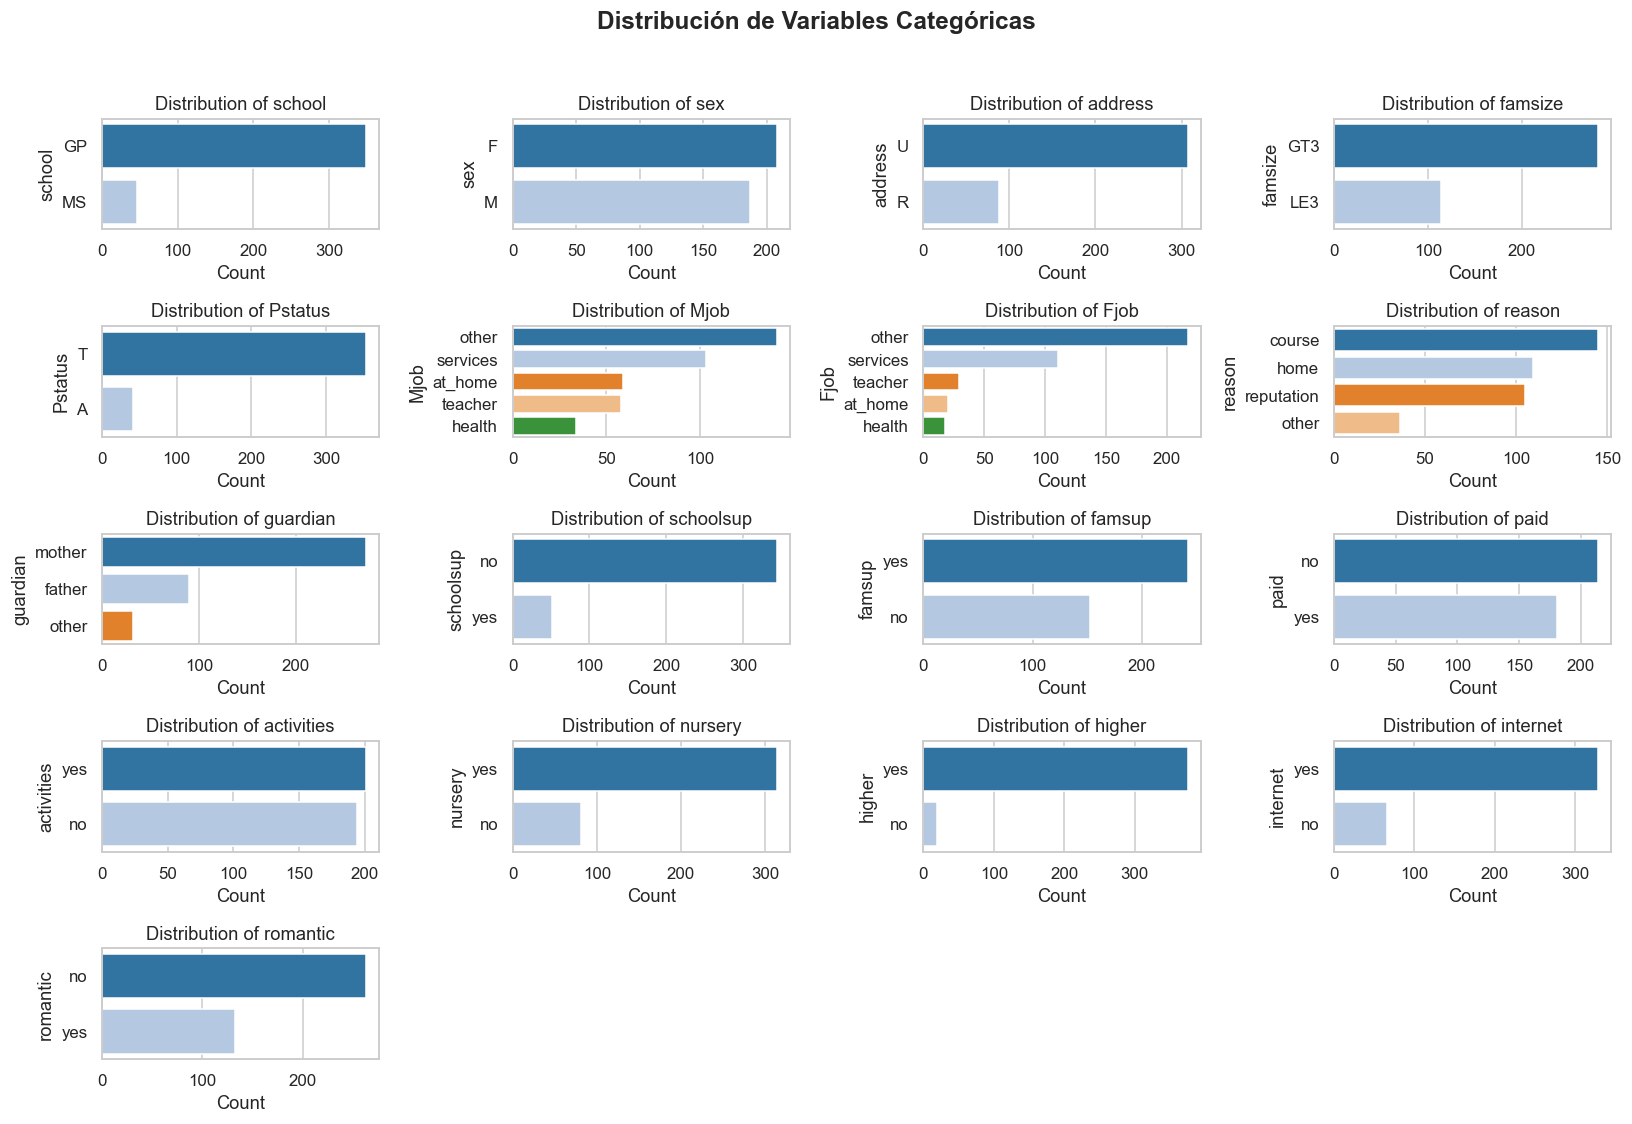


  DETECCIÓN OUTLIERS (IQR) — Matemáticas
  ⚠ age        Q1=16.0 Q3=18.0 IQR=2.0 límites=[13.0,21.0] outliers=1 (0.3%)
  ⚠ absences   Q1=0.0 Q3=8.0 IQR=8.0 límites=[-12.0,20.0] outliers=15 (3.8%)
  ✓ G1         Q1=8.0 Q3=13.0 IQR=5.0 límites=[0.5,20.5] outliers=0 (0.0%)
  ⚠ G2         Q1=9.0 Q3=13.0 IQR=4.0 límites=[3.0,19.0] outliers=13 (3.3%)
  ✓ G3         Q1=8.0 Q3=14.0 IQR=6.0 límites=[-1.0,23.0] outliers=0 (0.0%)


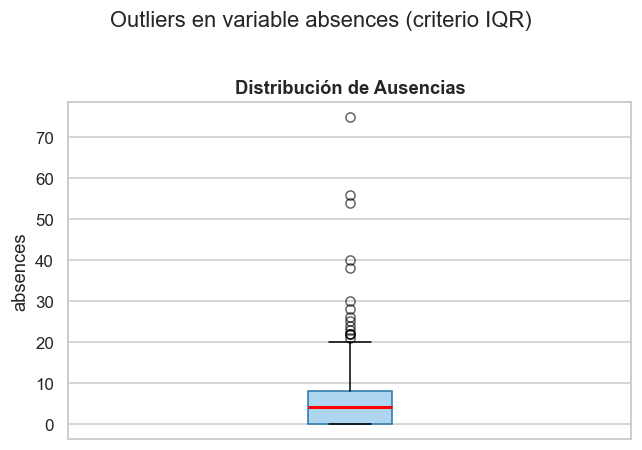


ANÁLISIS DE CORRELACIONES — Matemáticas

Variables numéricas consideradas: 16

Correlaciones con nota final G3:
G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


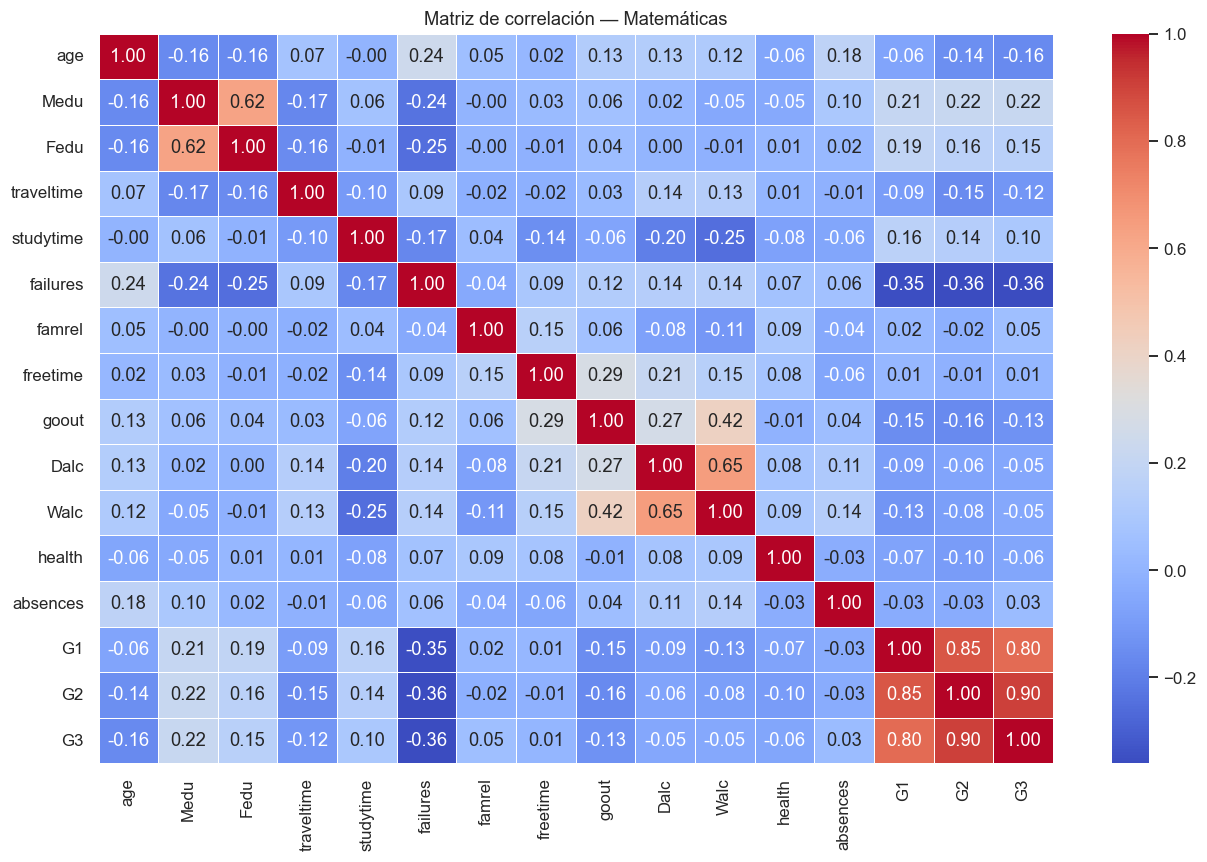


=== Análisis G3 = 0 ===
  Matemáticas: G3=0 total=38 | G2=0 y G3=0 (deserción)=13 | G2>0 y G3=0 (reprobado)=25


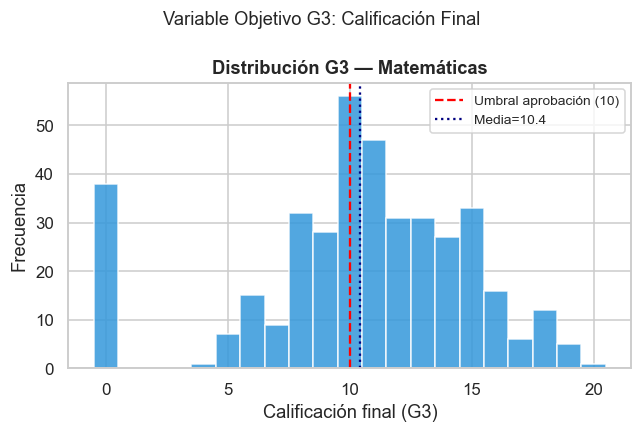


  Pipeline de limpieza — MAT
  [1] Duplicados eliminados : 0  (ninguno)
  [2] Strip en 17 columnas de texto ✓
  [3] Flag 'desercion' creado: 13 casos
  [4] Columna 'asignatura' = 'mat' ✓
  Resultado: 395 → 395 filas
  Winsorización 'absences': cap p95=18 → 20 valores ajustados
  Codificación binaria: 8 vars yes/no + 5 vars propias
  OHE aplicado en ['Mjob', 'Fjob', 'reason', 'guardian'] → 9 nuevas columnas
  Variables derivadas creadas: ['aprobado', 'progreso_g1_g3', 'nivel_alcohol', 'edu_familiar_media']

  Validando: Matemáticas
  ✓ Filas conservadas: 395
  ✓ Sin nulos en columnas originales
  ✓ G1, G2, G3 intactos
  ✓ Flag 'aprobado' coherente (265 aprobados)
  ✓ Flag 'desercion' coherente (13 casos)
  ✓ Sin filas duplicadas
  ✓ G1, G2, G3 en rango [0, 20]
  → VALIDACIÓN EXITOSA ✅
  ✓ student_mat_clean.csv                       395f ×  36c  (45.6 KB)
    → Matemáticas limpio: flags + winsorización (sin OHE)
  ✓ student_mat_clean_encode.csv                395f ×  54c  (48.5 KB)
    

In [5]:
# Pipeline Matemáticas
ok_mat = prep_mat.ejecutar_pipeline(exportar_resultados=True, base_path="../data/processed/F4/")

# Guardamos copias crudas ANTES de transformar (para las visualizaciones en Sección 6)
df_mat_raw = cargar_dataset(RUTA_MAT)
df_por_raw = cargar_dataset(RUTA_POR)


  PIPELINE — Portugués  (objeto: PreprocesadorPortugues)
Datos cargados desde CSV real: 649 filas x 33 columnas

Primeras filas:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5     

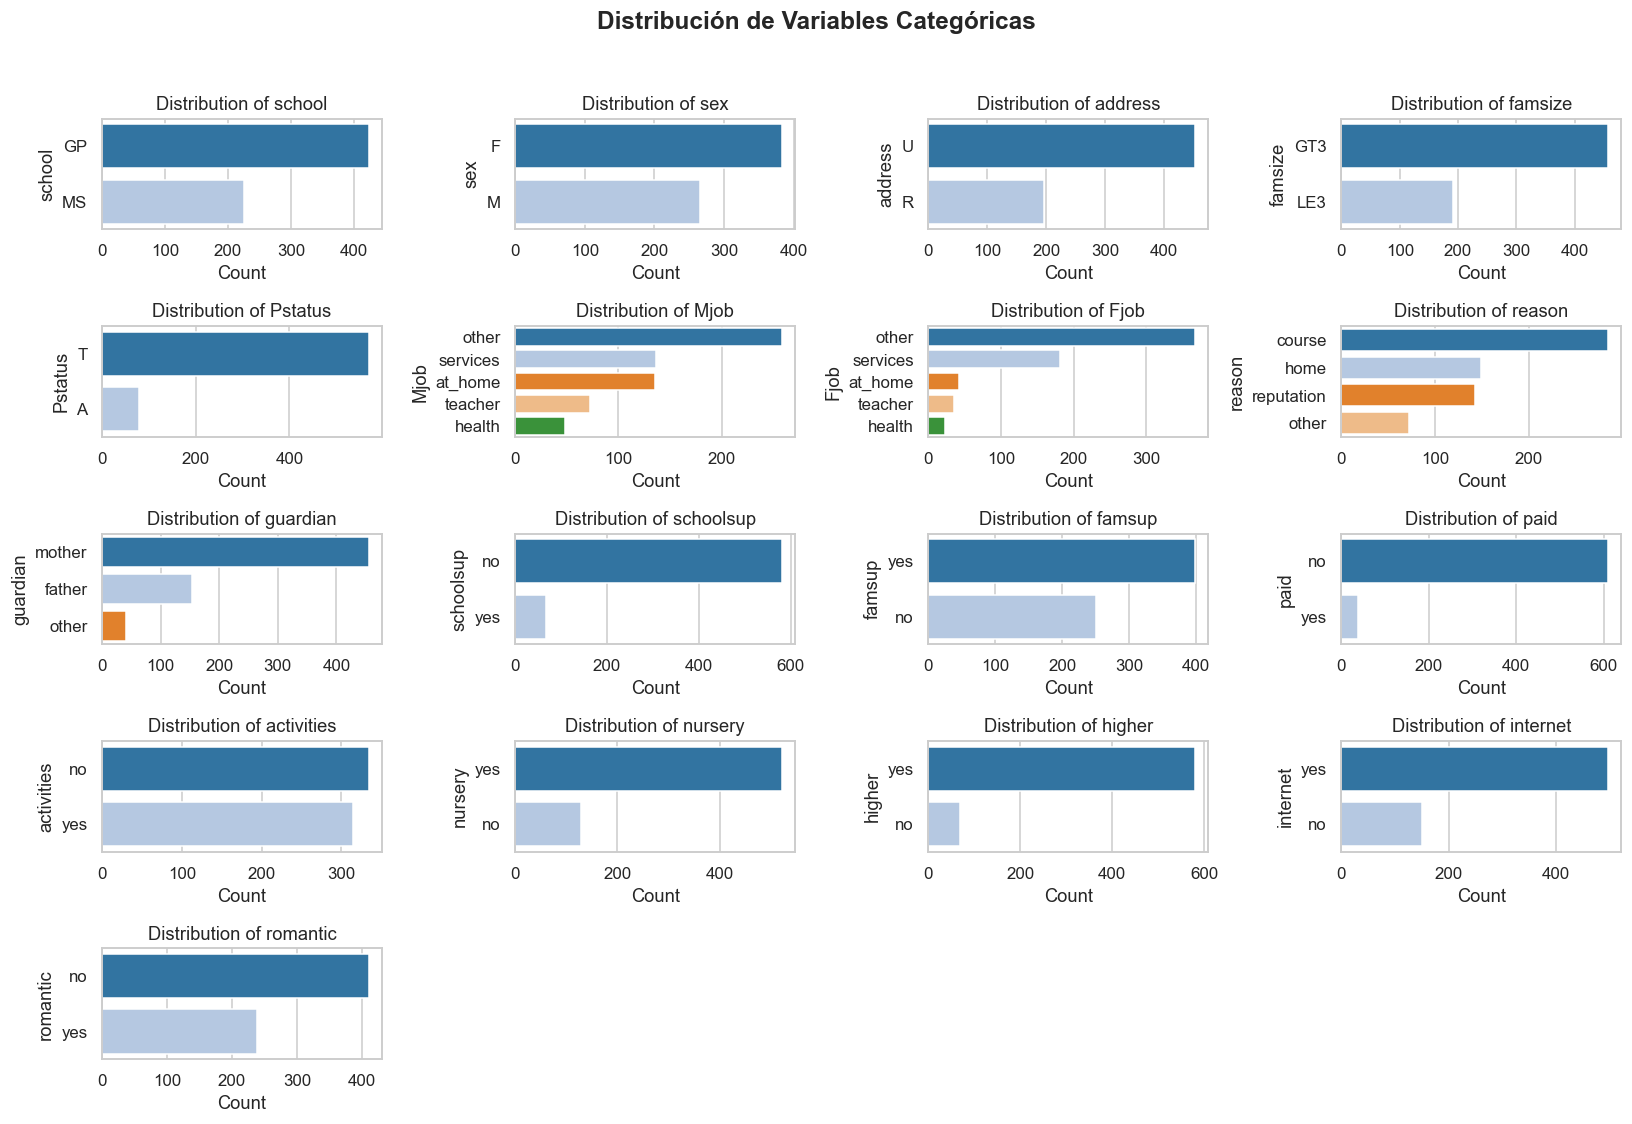


  DETECCIÓN OUTLIERS (IQR) — Portugués
  ⚠ age        Q1=16.0 Q3=18.0 IQR=2.0 límites=[13.0,21.0] outliers=1 (0.2%)
  ⚠ absences   Q1=0.0 Q3=6.0 IQR=6.0 límites=[-9.0,15.0] outliers=21 (3.2%)
  ⚠ G1         Q1=10.0 Q3=13.0 IQR=3.0 límites=[5.5,17.5] outliers=16 (2.5%)
  ⚠ G2         Q1=10.0 Q3=13.0 IQR=3.0 límites=[5.5,17.5] outliers=25 (3.9%)
  ⚠ G3         Q1=10.0 Q3=14.0 IQR=4.0 límites=[4.0,20.0] outliers=16 (2.5%)


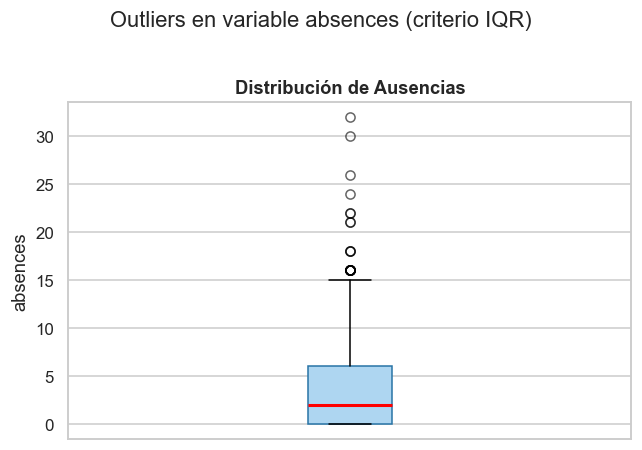


ANÁLISIS DE CORRELACIONES — Portugués

Variables numéricas consideradas: 16

Correlaciones con nota final G3:
G3            1.000000
G2            0.918548
G1            0.826387
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64


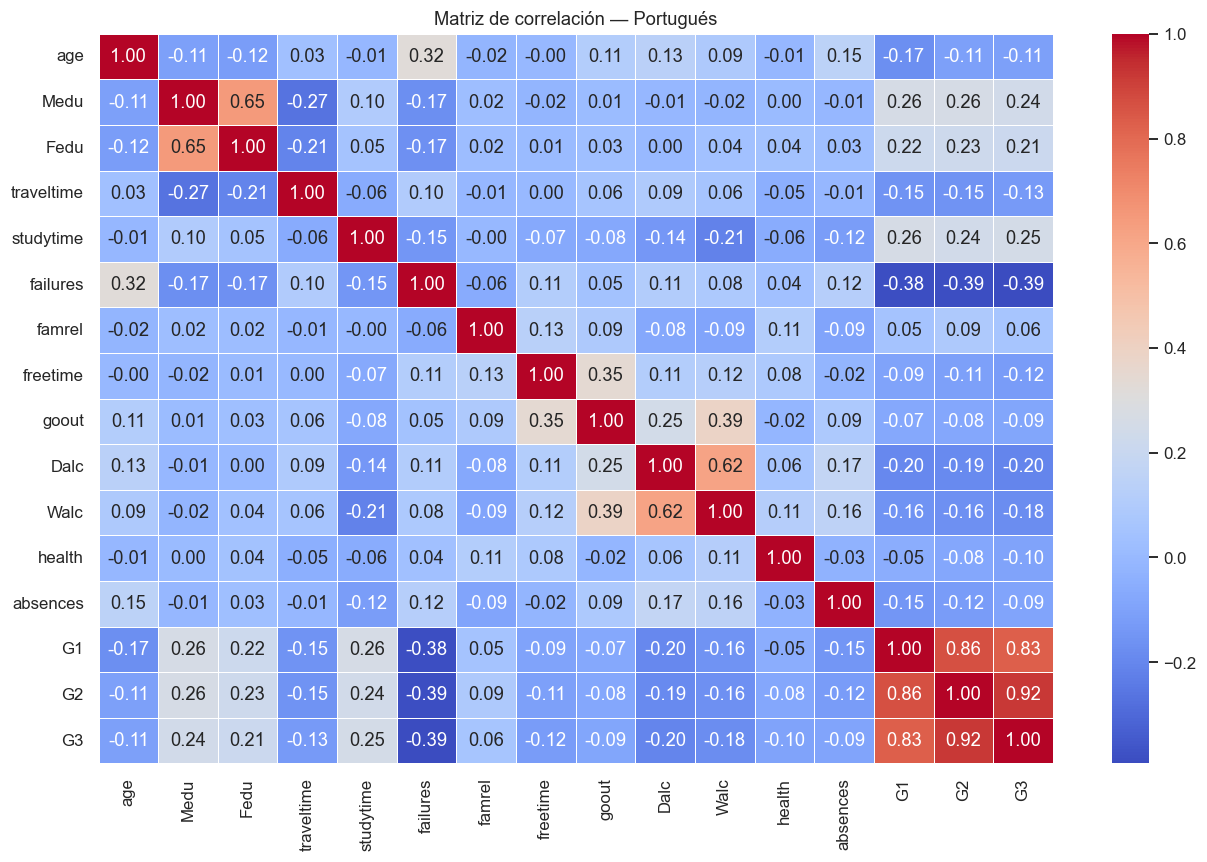


=== Análisis G3 = 0 ===
  Portugués: G3=0 total=15 | G2=0 y G3=0 (deserción)=7 | G2>0 y G3=0 (reprobado)=8


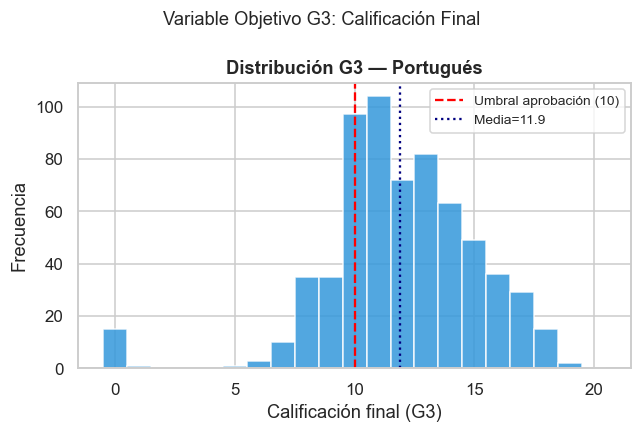


  Pipeline de limpieza — POR
  [1] Duplicados eliminados : 0  (ninguno)
  [2] Strip en 17 columnas de texto ✓
  [3] Flag 'desercion' creado: 7 casos
  [4] Columna 'asignatura' = 'por' ✓
  Resultado: 649 → 649 filas
  Winsorización 'absences': cap p95=12 → 32 valores ajustados
  Codificación binaria: 8 vars yes/no + 5 vars propias
  OHE aplicado en ['Mjob', 'Fjob', 'reason', 'guardian'] → 9 nuevas columnas
  Variables derivadas creadas: ['aprobado', 'progreso_g1_g3', 'nivel_alcohol', 'edu_familiar_media']

  Validando: Portugués
  ✓ Filas conservadas: 649
  ✓ Sin nulos en columnas originales
  ✓ G1, G2, G3 intactos
  ✓ Flag 'aprobado' coherente (549 aprobados)
  ✓ Flag 'desercion' coherente (7 casos)
  ✓ Sin filas duplicadas
  ✓ G1, G2, G3 en rango [0, 20]
  → VALIDACIÓN EXITOSA ✅
  ✓ student_por_clean.csv                       649f ×  36c  (72.8 KB)
    → Portugués limpio: flags + winsorización (sin OHE)
  ✓ student_por_clean_encode.csv                649f ×  54c  (77.7 KB)
    → Port

In [6]:
# Pipeline Portugués
ok_por = prep_por.ejecutar_pipeline(exportar_resultados=True, base_path="../data/processed/F4/")

In [7]:
# Estado final de los objetos tras el pipeline completo
print("Estado final de los objetos:")
print(" ", repr(prep_mat))
print(" ", repr(prep_por))

print(f"\nPipeline Matemáticas : {'✅ exitoso' if ok_mat else '❌ con errores'}")
print(f"Pipeline Portugués   : {'✅ exitoso' if ok_por else '❌ con errores'}")

# Resumen de dimensiones finales
print("\nDimensiones del dataset transformado (df_enc):")
print(f"  Matemáticas : {prep_mat.df_enc.shape[0]} filas × {prep_mat.df_enc.shape[1]} columnas")
print(f"  Portugués   : {prep_por.df_enc.shape[0]} filas × {prep_por.df_enc.shape[1]} columnas")

Estado final de los objetos:
  <PreprocesadorMatematicas asignatura='mat' | df=395 filas × 36 cols | df_enc=395 filas × 54 cols>
  <PreprocesadorPortugues asignatura='por' | df=649 filas × 36 cols | df_enc=649 filas × 54 cols>

Pipeline Matemáticas : ✅ exitoso
Pipeline Portugués   : ✅ exitoso

Dimensiones del dataset transformado (df_enc):
  Matemáticas : 395 filas × 54 columnas
  Portugués   : 649 filas × 54 columnas


### 4.3 Validación técnica del código

Se prueba el sistema bajo **tres escenarios** —caso normal, caso límite y excepción— con aserciones que dejan evidencia explícita y trazable de cada verificación. Esta batería de pruebas complementa la validación de integridad ya implementada en `validar_dataset_final()` (F2).

| Escenario | Qué se prueba | Resultado esperado |
|---|---|---|
| **Normal** | Pipeline completo sin nulos ni texto | Validación = True |
| **Límite** | Imputación sobre serie con 1 solo valor nulo | Sin error, serie retornada |
| **Excepción** | merge_sort sobre lista vacía | Lista vacía (caso base) |
| **Excepción** | aprobado_vectorizado sobre DataFrame sin G3 | KeyError controlado |

In [8]:
# ============================================================
# BATERÍA DE PRUEBAS TÉCNICAS
# ============================================================

def ejecutar_pruebas():
    """Batería de pruebas: caso normal, caso límite y manejo de excepciones."""
    resultados = []

    # ── 1. CASO NORMAL ────────────────────────────────────────────────────────
    # El pipeline completo debe dejar el df_enc sin nulos en columnas originales.
    cols_orig = [c for c in df_mat_raw.columns if c in prep_mat.df_enc.columns]
    nulos_enc = prep_mat.df_enc[cols_orig].isnull().sum().sum()
    assert nulos_enc == 0, f"Pipeline normal introduce nulos: {nulos_enc}"
    resultados.append(("Caso normal: pipeline sin nulos en columnas originales (mat)", "OK"))

    # Verificar que G1, G2, G3 no fueron modificados
    for col in ['G1', 'G2', 'G3']:
        assert (prep_mat.df_enc[col].values == df_mat_raw[col].values).all(), \
            f"Columna {col} fue modificada por el pipeline"
    resultados.append(("Caso normal: G1, G2, G3 intactos tras el pipeline", "OK"))

    # Flag aprobado coherente con G3
    esperado = (prep_mat.df_enc['G3'] >= 10).astype(int)
    assert (prep_mat.df_enc['aprobado'] == esperado).all(), \
        "Flag 'aprobado' inconsistente con G3"
    resultados.append(("Caso normal: flag 'aprobado' coherente con G3", "OK"))

    # ── 2. CASO LÍMITE ────────────────────────────────────────────────────────
    # Imputar una serie con un único NaN: no debe romperse.
    serie_un_nulo = pd.Series([np.nan])
    imputada = ImputarMediana().imputar(serie_un_nulo)
    assert len(imputada) == 1  # el tamaño se conserva
    resultados.append(("Caso límite: imputación sobre serie de 1 NaN no lanza error", "OK"))

    # merge_sort sobre lista vacía → debe retornar lista vacía (caso base)
    assert merge_sort([]) == [], "merge_sort([]) debe retornar []"
    resultados.append(("Caso límite: merge_sort([]) retorna lista vacía (caso base)", "OK"))

    # merge_sort sobre lista de 1 elemento → caso base
    assert merge_sort([7]) == [7], "merge_sort([7]) debe retornar [7]"
    resultados.append(("Caso límite: merge_sort con 1 elemento retorna sin recursión", "OK"))

    # ── 3. MANEJO DE EXCEPCIONES ──────────────────────────────────────────────
    # aprobado_vectorizado con DataFrame sin columna G3 → KeyError
    df_sin_g3 = prep_mat.df_enc.drop(columns=['G3'])
    lanzo_key_error = False
    try:
        aprobado_vectorizado(df_sin_g3)
    except KeyError:
        lanzo_key_error = True
    assert lanzo_key_error, "aprobado_vectorizado debe lanzar KeyError sin columna G3"
    resultados.append(("Excepción: aprobado_vectorizado lanza KeyError sin columna G3", "OK"))

    # EstrategiaImputacion (abstracta) no puede instanciarse directamente → TypeError
    lanzo_type_error = False
    try:
        EstrategiaImputacion()  # clase abstracta
    except TypeError:
        lanzo_type_error = True
    assert lanzo_type_error, "EstrategiaImputacion no debe poder instanciarse"
    resultados.append(("Excepción: EstrategiaImputacion abstracta lanza TypeError", "OK"))

    # PreprocesadorAsignatura.interpretar_resultados() → NotImplementedError
    base = PreprocesadorAsignatura(ruta=RUTA_MAT, asignatura='mat')
    lanzo_not_impl = False
    try:
        base.interpretar_resultados()
    except NotImplementedError:
        lanzo_not_impl = True
    assert lanzo_not_impl, "La clase base debe lanzar NotImplementedError"
    resultados.append(("Excepción: clase base lanza NotImplementedError (contrato POO)", "OK"))

    return resultados


print("=" * 65)
print("  BATERÍA DE PRUEBAS TÉCNICAS")
print("=" * 65)
for descripcion, estado in ejecutar_pruebas():
    print(f"  [{estado}] {descripcion}")
print("\n  Todas las pruebas pasaron correctamente. ✅")

  BATERÍA DE PRUEBAS TÉCNICAS
  [OK] Caso normal: pipeline sin nulos en columnas originales (mat)
  [OK] Caso normal: G1, G2, G3 intactos tras el pipeline
  [OK] Caso normal: flag 'aprobado' coherente con G3
  [OK] Caso límite: imputación sobre serie de 1 NaN no lanza error
  [OK] Caso límite: merge_sort([]) retorna lista vacía (caso base)
  [OK] Caso límite: merge_sort con 1 elemento retorna sin recursión
  [OK] Excepción: aprobado_vectorizado lanza KeyError sin columna G3
  [OK] Excepción: EstrategiaImputacion abstracta lanza TypeError
  [OK] Excepción: clase base lanza NotImplementedError (contrato POO)

  Todas las pruebas pasaron correctamente. ✅


### 4.4 Eficiencia y optimización — benchmarks con `timeit`

Se comparan **dos implementaciones** de la misma tarea: calcular si cada estudiante aprobó (`G3 >= 10`), ya implementadas en `functions.py` desde la Fase 3:

- **Implementación A (bucle `iterrows`):** recorre fila por fila en Python puro → **O(n)** con alto costo constante.
- **Implementación B (vectorizada Pandas):** opera sobre el array completo en C/NumPy → también **O(n)** pero con factor constante mucho menor.

Se verifica primero que ambas producen el **mismo resultado** y luego se cronometran con `timeit`, agregando en esta fase la comparativa sobre **ambos datasets** (Matemáticas y Portugués) para mostrar cómo escala la diferencia con el tamaño de los datos.

In [9]:
# ============================================================
# BENCHMARK: bucle vs vectorizado en ambos datasets
# ============================================================
N = 500  # repeticiones para timeit

resultados_bench = {}

for nombre, df_bench in [("Matemáticas", prep_mat.df), ("Portugués", prep_por.df)]:
    # Verificar equivalencia de resultados
    res_bucle = aprobado_bucle(df_bench)
    res_vec   = aprobado_vectorizado(df_bench).tolist()
    assert res_bucle == res_vec, f"Los resultados difieren en {nombre}"

    t_bucle = timeit.timeit(lambda df=df_bench: aprobado_bucle(df),       number=N)
    t_vec   = timeit.timeit(lambda df=df_bench: aprobado_vectorizado(df),  number=N)
    aceleracion = t_bucle / t_vec

    resultados_bench[nombre] = {
        'n_filas': len(df_bench),
        't_bucle': t_bucle,
        't_vec': t_vec,
        'aceleracion': aceleracion
    }

    print(f"\n── {nombre} (n={len(df_bench)} filas, {N} repeticiones) ──")
    print(f"  Bucle (iterrows) : {t_bucle:.4f} s")
    print(f"  Vectorizado      : {t_vec:.4f} s")
    print(f"  Aceleración      : ~{aceleracion:.0f}x más rápido")

print("\n✅ Ambas versiones producen resultados idénticos.")


── Matemáticas (n=395 filas, 500 repeticiones) ──
  Bucle (iterrows) : 16.4747 s
  Vectorizado      : 0.0932 s
  Aceleración      : ~177x más rápido

── Portugués (n=649 filas, 500 repeticiones) ──
  Bucle (iterrows) : 26.3929 s
  Vectorizado      : 0.0938 s
  Aceleración      : ~281x más rápido

✅ Ambas versiones producen resultados idénticos.


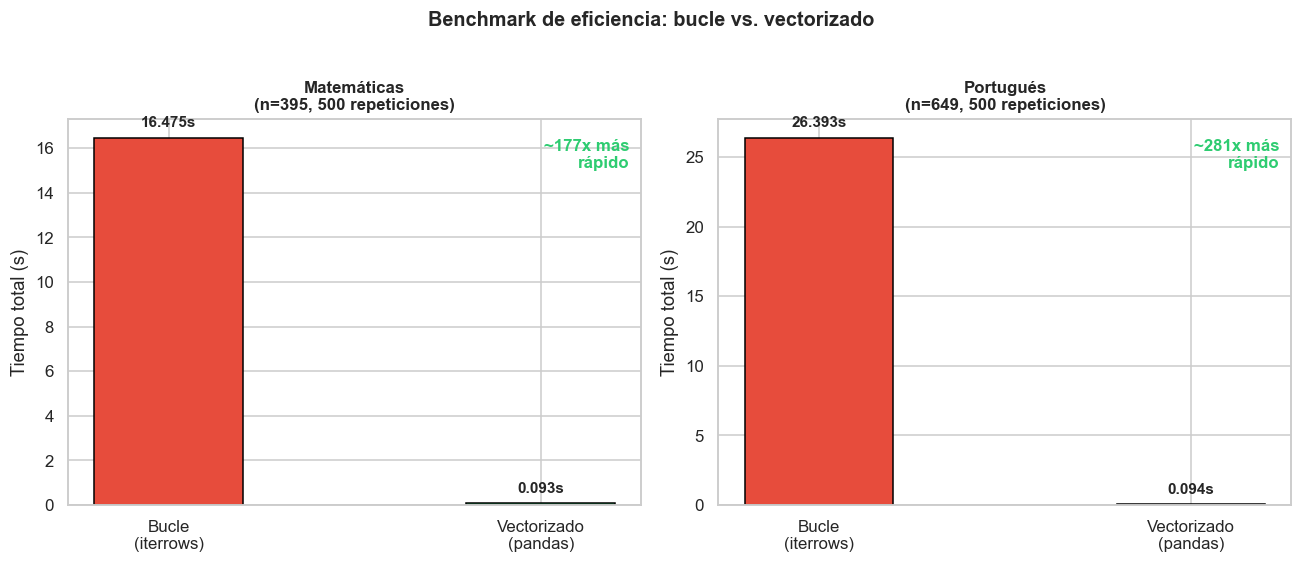


Interpretación:
  Ambas implementaciones comparten complejidad asintótica O(n), pero la versión
  vectorizada es órdenes de magnitud más rápida porque ejecuta el bucle en código
  compilado (C/NumPy) en lugar del intérprete de Python. Al pasar de Matemáticas
  (395 filas) a Portugués (649 filas), el tiempo del bucle escala linealmente
  mientras que el vectorizado apenas varía, evidenciando la ventaja de Pandas para
  grandes volúmenes de datos.

  Decisión técnica: se adopta la implementación vectorizada en todo el pipeline.



In [10]:
# ── Visualización comparativa de los benchmarks ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colores = ["#E74C3C", "#2ECC71"]

for ax, (nombre, datos) in zip(axes, resultados_bench.items()):
    barras = ax.bar(
        ["Bucle\n(iterrows)", "Vectorizado\n(pandas)"],
        [datos['t_bucle'], datos['t_vec']],
        color=colores, width=0.4, edgecolor='black'
    )
    for bar, val in zip(barras, [datos['t_bucle'], datos['t_vec']]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + datos['t_bucle'] * 0.02,
                f"{val:.3f}s", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f"{nombre}\n(n={datos['n_filas']}, {N} repeticiones)",
                 fontsize=11, fontweight='bold')
    ax.set_ylabel("Tiempo total (s)")
    ax.text(0.98, 0.95, f"~{datos['aceleracion']:.0f}x más\nrápido",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=11, color='#2ECC71', fontweight='bold')

plt.suptitle("Benchmark de eficiencia: bucle vs. vectorizado",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../data/processed/F4/', exist_ok=True)
plt.savefig('../data/processed/F4/fig_benchmark_eficiencia.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
Interpretación:
  Ambas implementaciones comparten complejidad asintótica O(n), pero la versión
  vectorizada es órdenes de magnitud más rápida porque ejecuta el bucle en código
  compilado (C/NumPy) en lugar del intérprete de Python. Al pasar de Matemáticas
  (395 filas) a Portugués (649 filas), el tiempo del bucle escala linealmente
  mientras que el vectorizado apenas varía, evidenciando la ventaja de Pandas para
  grandes volúmenes de datos.

  Decisión técnica: se adopta la implementación vectorizada en todo el pipeline.
""")

### 4.5 Diseño estructurado y recursividad

El algoritmo recursivo **Merge Sort** (implementado en F3 en `functions.py`) se aplica aquí con un análisis de complejidad más detallado y una comparativa adicional contra `sorted()` de Python —que usa TimSort, O(n log n)— para mostrar que ambos convergen en resultado pero difieren en rendimiento práctico por las constantes de implementación.

**Análisis de complejidad de merge_sort:**
- **Tiempo:** O(n log n) — cada nivel de recursión procesa n elementos; hay log₂(n) niveles.
- **Espacio:** O(n) — se crean listas auxiliares en cada nivel de combinación.
- **Caso base:** lista de 0 o 1 elementos → ya ordenada, retorna sin llamada recursiva.
- **Caso recursivo:** divide a la mitad → ordena cada parte → combina. El problema se reduce en cada llamada, garantizando terminación.

In [11]:
# ============================================================
# RECURSIVIDAD: Merge Sort aplicado al dataset
# ============================================================

# ── Ordenar G3 de ambas asignaturas ──────────────────────────
g3_mat = prep_mat.df['G3'].dropna().tolist()
g3_por = prep_por.df['G3'].dropna().tolist()

print("── Matemáticas — G3 (primeros 39 valores) ──")
print("  Original :", g3_mat[:39])
print("  Ordenado :", merge_sort(g3_mat)[:39])

print("\n── Portugués — G3 (primeros 20 valores) ──")
print("  Original :", g3_por[:20])
print("  Ordenado :", merge_sort(g3_por)[:20])

# ── Validación contra sorted() ───────────────────────────────
assert merge_sort(g3_mat) == sorted(g3_mat), "Error en Merge Sort — Matemáticas"
assert merge_sort(g3_por) == sorted(g3_por), "Error en Merge Sort — Portugués"
print("\n✓ Verificación: merge_sort produce el mismo resultado que sorted().")

# ── Benchmark merge_sort vs sorted ───────────────────────────
N_ms = 200
t_merge = timeit.timeit(lambda: merge_sort(g3_por[:]), number=N_ms)
t_sorted = timeit.timeit(lambda: sorted(g3_por[:]), number=N_ms)

print(f"\nBenchmark sobre G3 Portugués (n={len(g3_por)}, {N_ms} repeticiones):")
print(f"  merge_sort (Python puro): {t_merge:.4f} s")
print(f"  sorted (TimSort en C)   : {t_sorted:.4f} s")
print(f"  sorted es ~{t_merge/t_sorted:.0f}x más rápido")
print("""
Interpretación: ambos son O(n log n), pero sorted() usa TimSort implementado
en C, lo que lo hace mucho más rápido en la práctica. merge_sort aquí tiene
valor pedagógico: ilustra el patrón recursivo divide-y-vencerás de forma
explícita y legible.""")

── Matemáticas — G3 (primeros 39 valores) ──
  Original : [6, 6, 10, 15, 10, 15, 11, 6, 19, 15, 9, 12, 14, 11, 16, 14, 14, 10, 5, 10, 15, 15, 16, 12, 8, 8, 11, 15, 11, 11, 12, 17, 16, 12, 15, 6, 18, 15, 11]
  Ordenado : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4]

── Portugués — G3 (primeros 20 valores) ──
  Original : [11, 11, 12, 14, 13, 13, 13, 13, 17, 13, 14, 13, 12, 13, 15, 17, 14, 14, 7, 12]
  Ordenado : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 5, 6, 6, 6]

✓ Verificación: merge_sort produce el mismo resultado que sorted().

Benchmark sobre G3 Portugués (n=649, 200 repeticiones):
  merge_sort (Python puro): 0.4013 s
  sorted (TimSort en C)   : 0.0107 s
  sorted es ~38x más rápido

Interpretación: ambos son O(n log n), pero sorted() usa TimSort implementado
en C, lo que lo hace mucho más rápido en la práctica. merge_sort aquí tiene
valor pedagógico: ilustra el patrón recursivo divide-y-vencerás de fo

---
<a id='5'></a>
## 5. Implementación de código modular y robusto (POO)

La arquitectura desarrollada a lo largo de F3 y F4 cumple los cuatro pilares de la POO:

| Pilar | Implementación en el proyecto |
|---|---|
| **Encapsulamiento** | `self.df`, `self.df_raw`, `self.df_enc` son atributos internos del objeto; se accede a ellos por los métodos del pipeline, no directamente |
| **Herencia** | `PreprocesadorMatematicas` y `PreprocesadorPortugues` heredan de `PreprocesadorAsignatura`, reutilizando el pipeline completo sin duplicar código |
| **Polimorfismo** | `interpretar_resultados()` tiene la misma firma en ambas clases hijas, pero comportamiento distinto según la asignatura |
| **Abstracción** | `EstrategiaImputacion` (F4) define una interfaz abstracta; `interpretar_resultados()` actúa como contrato de implementación en la clase base |

A continuación se demuestra el **polimorfismo en acción** y se inspeccionan los atributos del objeto tras el pipeline.

In [12]:
# ============================================================
# POLIMORFISMO: mismo método, distinto comportamiento
# ============================================================
prep_mat.interpretar_resultados()
prep_por.interpretar_resultados()


  INTERPRETACIÓN — Matemáticas

        Las variables con mayor relación positiva con G3 corresponden a las
        notas de períodos anteriores: G2 (0.90) y G1 (0.80), lo que indica
        que el desempeño previo es el principal predictor del rendimiento final.

        En menor medida, el nivel educativo de la madre (Medu=0.22) y del
        padre (Fedu=0.15) muestran correlaciones positivas débiles.

        La variable con mayor asociación negativa es 'failures' (-0.36):
        los estudiantes con más asignaturas reprobadas previamente tienden
        a obtener notas finales más bajas. Las variables de hábitos (goout,
        Dalc, Walc) presentan asociaciones débiles.
        

  INTERPRETACIÓN — Portugués

  Igual que en Matemáticas, las notas previas dominan la correlación
  con G3: G2 (0.92) y G1 (0.83) son los predictores más fuertes.

  A diferencia de Matemáticas, aquí el tiempo de estudio (studytime=0.25)
  y el nivel educativo de la madre (Medu=0.24) tienen un peso algo

In [13]:
# ── La clase base no implementa interpretar_resultados() ─────
# Esto garantiza que toda subclase concreta defina su propia versión
base = PreprocesadorAsignatura(ruta=RUTA_MAT, asignatura='mat')
try:
    base.interpretar_resultados()
except NotImplementedError as e:
    print(f"NotImplementedError (esperado): {e}")

# ── Inspección del estado encapsulado del objeto ─────────────
print("\nAtributos del objeto prep_mat tras el pipeline:")
print(f"  asignatura        : {prep_mat.asignatura}")
print(f"  NOMBRE_ASIGNATURA : {prep_mat.NOMBRE_ASIGNATURA}")
print(f"  df_raw.shape      : {prep_mat.df_raw.shape}")
print(f"  df.shape          : {prep_mat.df.shape}")
print(f"  df_enc.shape      : {prep_mat.df_enc.shape}")
print(f"  Flag desercion    : {prep_mat.df['desercion'].sum()} casos")
print(f"  Aprobados         : {prep_mat.df_enc['aprobado'].sum()} de {len(prep_mat.df_enc)}")
print(f"\nRepresentación __repr__:\n  {repr(prep_mat)}")

NotImplementedError (esperado): interpretar_resultados() debe implementarse en la subclase correspondiente (PreprocesadorMatematicas / PreprocesadorPortugues).

Atributos del objeto prep_mat tras el pipeline:
  asignatura        : mat
  NOMBRE_ASIGNATURA : Matemáticas
  df_raw.shape      : (395, 33)
  df.shape          : (395, 36)
  df_enc.shape      : (395, 54)
  Flag desercion    : 13 casos
  Aprobados         : 265 de 395

Representación __repr__:
  <PreprocesadorMatematicas asignatura='mat' | df=395 filas × 36 cols | df_enc=395 filas × 54 cols>


In [14]:
# ── Patrón Strategy + herencia POO: integración completa ─────
# Demostramos que el patrón Strategy es compatible con la arquitectura
# POO del proyecto: la estrategia se inyecta de forma independiente
# de la clase que la usa.
print("Patrón Strategy — demostración con datos del proyecto:")
for estrategia in [ImputarMediana(), ImputarMedia()]:
    # Aplicar sobre la columna G3 como si tuviera nulos (simulación)
    g3_con_nulos = prep_mat.df['G3'].copy().astype(float)
    g3_con_nulos.iloc[0] = np.nan  # simulamos 1 nulo
    g3_imputada = estrategia.imputar(g3_con_nulos)
    print(f"  Estrategia {estrategia.nombre:<14}: valor imputado = {g3_imputada.iloc[0]:.2f}")

print("\n→ Misma interfaz (imputar), distinto comportamiento. Eso es el patrón Strategy.")

Patrón Strategy — demostración con datos del proyecto:
  Estrategia ImputarMediana: valor imputado = 11.00
  Estrategia ImputarMedia  : valor imputado = 10.43

→ Misma interfaz (imputar), distinto comportamiento. Eso es el patrón Strategy.


---
<a id='6'></a>
## 6. Construcción de visualizaciones de datos efectivas

Se presentan **cinco visualizaciones** que responden directamente a las preguntas de investigación definidas en F1. Cada gráfico incluye título descriptivo, ejes etiquetados, leyenda y escala adecuada, y se acompaña de su interpretación analítica. Se calculan sobre los datos crudos (`df_mat_raw`, `df_por_raw`) para preservar las unidades originales (notas en escala 0–20, ausencias en días, etc.).

| Figura | Pregunta que responde | Tipo de gráfico |
|:---:|---|---|
| 1 | Distribución de G3 y tasa de aprobación por asignatura | Histograma comparativo |
| 2 | Relación entre hábitos de estudio y rendimiento final (G3) | Boxplot por studytime |
| 3 | Perfil comparativo de estudiantes según historial de reprobaciones: 0 vs. 3+ reprobaciones | Grafico de Radar por historial de reprobaciones|
| 4 | Variables con mayor correlación con G3 | Heatmap de correlaciones |
| 5 | Diferencias de rendimiento entre establecimientos y por sexo | Barplot comparativo |

In [15]:
# ── Configuración visual global ───────────────────────────────
PALETA = {'mat': '#3498DB', 'por': '#E67E22'}
OUTPUT_DIR = '../data/processed/F4/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Directorio de figuras creado:", OUTPUT_DIR)

Directorio de figuras creado: ../data/processed/F4/


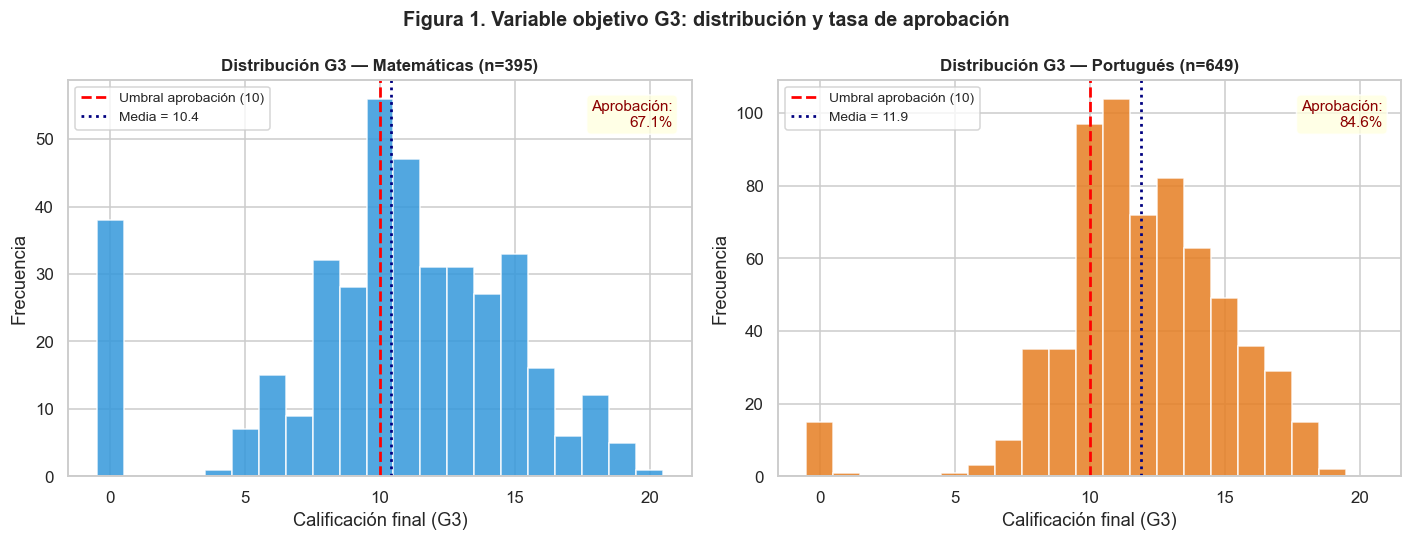


Interpretación (Fig. 1):
  Las calificaciones finales en Matemáticas se concentran entre 8 y 14 puntos
  (media ≈10.4), con una distribución bimodal leve y una cola de G3=0 atribuible
  a deserciones. En Portugués, la distribución es más homogénea y desplazada hacia
  valores más altos (media ≈11.9), con mayor proporción de estudiantes sobre el
  umbral de aprobación (10 puntos).



In [16]:
# ──────────────────────────────────────────────────────────────
# FIGURA 1: Distribución de G3 y tasa de aprobación
# Responde: ¿Cómo se distribuye el rendimiento final?
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, titulo, color in zip(
        axes,
        [df_mat_raw, df_por_raw],
        ['Matemáticas (n=395)', 'Portugués (n=649)'],
        [PALETA['mat'], PALETA['por']]):

    ax.hist(df['G3'], bins=21, range=(-0.5, 20.5),
            color=color, edgecolor='white', alpha=0.85)
    ax.axvline(10, color='red', linestyle='--', linewidth=1.8, label='Umbral aprobación (10)')
    ax.axvline(df['G3'].mean(), color='navy', linestyle=':', linewidth=1.8,
               label=f"Media = {df['G3'].mean():.1f}")

    tasa_aprob = (df['G3'] >= 10).mean() * 100
    ax.text(0.97, 0.95, f"Aprobación:\n{tasa_aprob:.1f}%",
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    ax.set_title(f'Distribución G3 — {titulo}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Calificación final (G3)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Figura 1. Variable objetivo G3: distribución y tasa de aprobación',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}fig1_distribucion_g3.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
Interpretación (Fig. 1):
  Las calificaciones finales en Matemáticas se concentran entre 8 y 14 puntos
  (media ≈10.4), con una distribución bimodal leve y una cola de G3=0 atribuible
  a deserciones. En Portugués, la distribución es más homogénea y desplazada hacia
  valores más altos (media ≈11.9), con mayor proporción de estudiantes sobre el
  umbral de aprobación (10 puntos).
""")

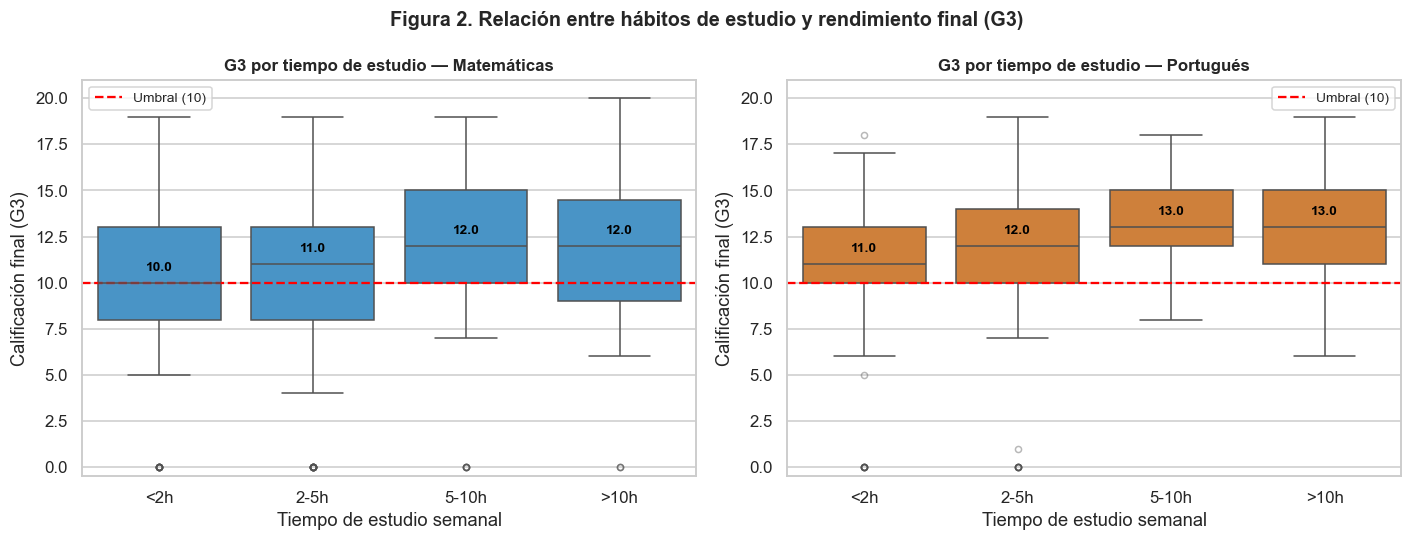


Interpretación (Fig. 2):
  En Portugués se observa una tendencia positiva más clara: a mayor tiempo de estudio,
  mayor mediana de G3 (correlación = 0.25, F2). En Matemáticas la tendencia existe
  pero es más débil (correlación = 0.10, F2), con mayor dispersión en todos los grupos.
  El grupo '<2h' presenta las medianas más bajas en ambas asignaturas
   En todos los grupos de estudio, las medianas se sitúan en torno o por encima de la nota 10,
   lo que indica que más del 50 % de los estudiantes de cada categoría logra aprobar.

  Estudiar más de 10 horas en Matemáticas no aumenta la mediana (se queda en 12.0) e incluso expande el bigote inferior, lo que significa 
  que a algunos estudiantes no les dio tan buen resultado o sufrieron de "rendimientos decrecientes". 
  Mientras que en Portugués se mantiene la mediana con el rango anterior.

  En ambas asignaturas se observa una relación positiva entre el tiempo de estudio y la calificación final, siendo esta asociación 
  más marcada e

In [17]:
# ──────────────────────────────────────────────────────────────
# FIGURA 2: Hábitos de estudio y rendimiento (G3)
# Responde: ¿Influye el tiempo de estudio en las calificaciones?
# ──────────────────────────────────────────────────────────────
etiquetas_study = {1: '<2h', 2: '2-5h', 3: '5-10h', 4: '>10h'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, titulo, color in zip(
        axes,
        [df_mat_raw, df_por_raw],
        ['Matemáticas', 'Portugués'],
        [PALETA['mat'], PALETA['por']]):

    df_plot = df.copy()
    df_plot['studytime_label'] = df_plot['studytime'].map(etiquetas_study)
    orden = ['<2h', '2-5h', '5-10h', '>10h']

    sns.boxplot(data=df_plot, x='studytime_label', y='G3',
                order=orden, color=color, ax=ax,
                flierprops=dict(marker='o', alpha=0.4, markersize=4))
    ax.axhline(10, color='red', linestyle='--', linewidth=1.5, label='Umbral (10)')
    ax.set_title(f'G3 por tiempo de estudio — {titulo}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Tiempo de estudio semanal')
    ax.set_ylabel('Calificación final (G3)')
    ax.set_ylim(-0.5, 21)
    ax.legend(fontsize=9)

    medias = df_plot.groupby('studytime_label')['G3'].median().reindex(orden)
    for i, (cat, med) in enumerate(medias.items()):
        ax.text(i, med + 0.5, f'{med:.1f}', ha='center', va='bottom',
                fontsize=9, color='black', fontweight='bold')

plt.suptitle('Figura 2. Relación entre hábitos de estudio y rendimiento final (G3)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}fig2_studytime_vs_g3.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
Interpretación (Fig. 2):
  En Portugués se observa una tendencia positiva más clara: a mayor tiempo de estudio,
  mayor mediana de G3 (correlación = 0.25, F2). En Matemáticas la tendencia existe
  pero es más débil (correlación = 0.10, F2), con mayor dispersión en todos los grupos.
  El grupo '<2h' presenta las medianas más bajas en ambas asignaturas
   En todos los grupos de estudio, las medianas se sitúan en torno o por encima de la nota 10,
   lo que indica que más del 50 % de los estudiantes de cada categoría logra aprobar.
      
  Estudiar más de 10 horas en Matemáticas no aumenta la mediana (se queda en 12.0) e incluso expande el bigote inferior, lo que significa 
  que a algunos estudiantes no les dio tan buen resultado o sufrieron de "rendimientos decrecientes". 
  Mientras que en Portugués se mantiene la mediana con el rango anterior.

  En ambas asignaturas se observa una relación positiva entre el tiempo de estudio y la calificación final, siendo esta asociación 
  más marcada en Portugués. No obstante, el rendimiento académico también  parece estar influenciado por otros factores además del tiempo 
      dedicado al estudio.   
      
      """)

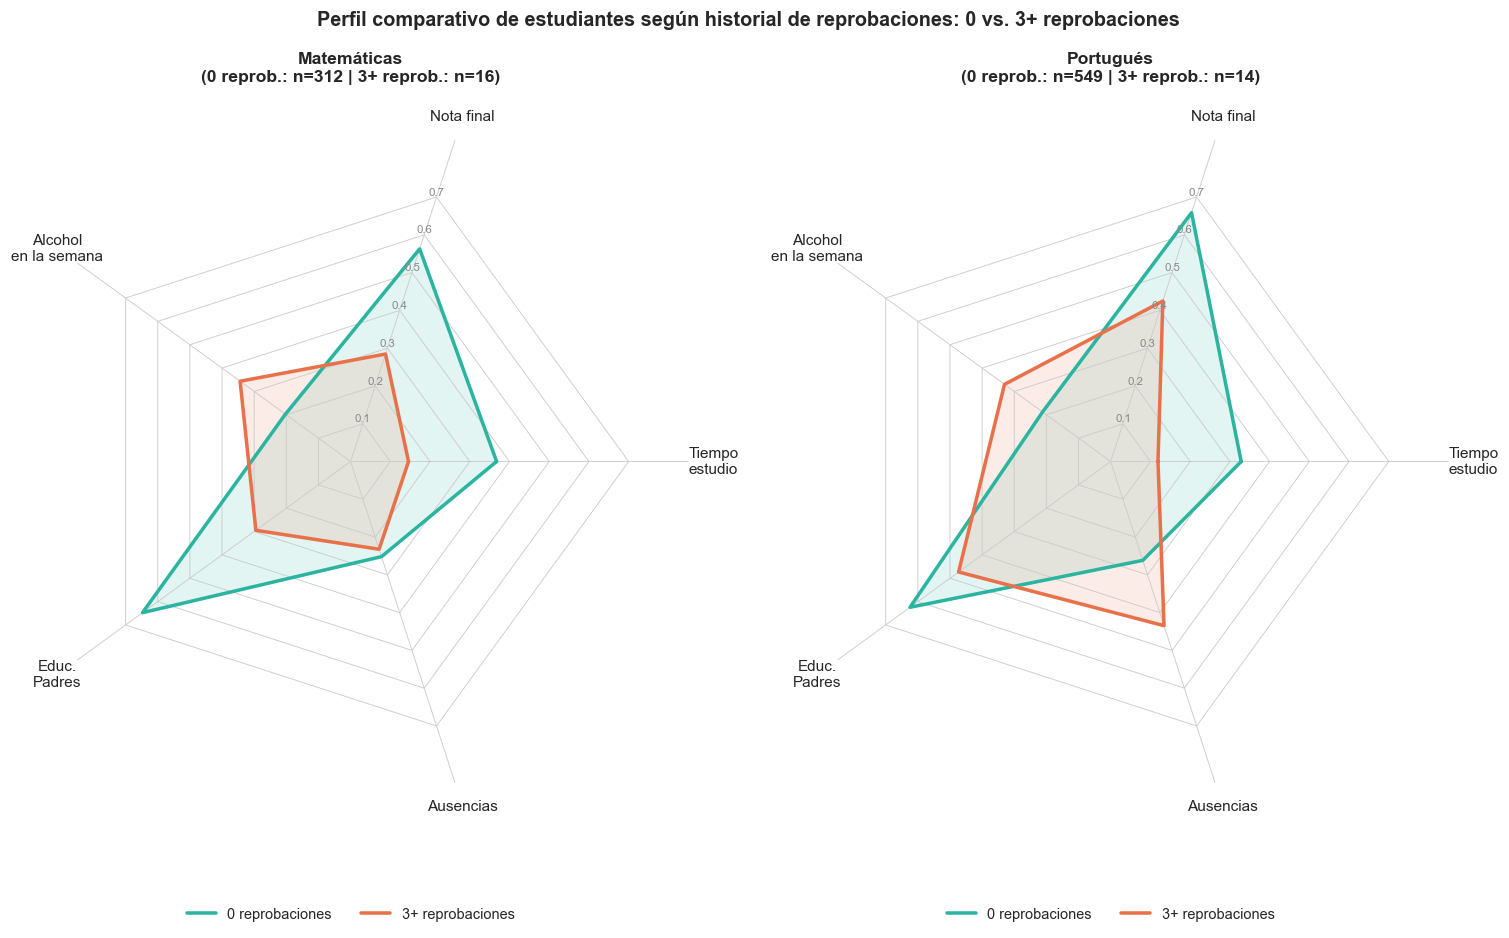

In [18]:
# ──────────────────────────────────────────────────────────────
# FIGURA 3: Perfil comparativo de estudiantes según historial de reprobaciones: 0 vs. 3+ reprobaciones
# Responde: ¿De qué manera los hábitos de estudio y el entorno familiar se asocian con el historial de reprobaciones de los estudiantes?
# ──────────────────────────────────────────────────────────────
plot_radar_reprobaciones(prep_mat.df_enc, prep_por.df_enc)

Interpretación:
Lo primero que salta a la vista es que el polígono verde (0 reprobaciones) es consistentemente más grande que el naranja (3+) en ambas asignaturas, lo que confirma visualmente el hallazgo de correlación de la Fase 2 (failures = -0.36 en Matemáticas, -0.39 en Portugués).

Analizando eje por eje:
Nota final (G3): la diferencia más pronunciada en ambos gráficos. Los estudiantes sin reprobaciones obtienen notas finales notablemente más altas, lo que es coherente con que failures sea la variable influyente de forma negativa más fuerte de G3 de todo el dataset.

Tiempo de estudio: los estudiantes con 0 reprobaciones también dedican más horas semanales al estudio. Esto sugiere que las reprobaciones no son solo consecuencia de menor capacidad, sino de hábitos de estudio menos consolidados.

Educación de los padres(edu_familiar_media*): los estudiantes con 3+ reprobaciones provienen de hogares con menor nivel educativo parental promedio, especialmente en Portugués. Esto conecta con el hallazgo de Fase 2 sobre el rol del capital cultural familiar (Medu = 0.22 en Matemáticas, 0.24 en Portugués).

Alcohol en la semana (nivel_alcohol*): a diferencia de los otros ejes, aquí el grupo con más reprobaciones muestra valores iguales o superiores al grupo sin reprobaciones, lo que es coherente con las correlaciones negativas de Fase 2 entre consumo de alcohol y rendimiento, más marcadas en Portugués.

Ausencias: el grupo con 3+ reprobaciones acumula más ausencias en ambas asignaturas, aunque la diferencia es menos pronunciada que en nota final o tiempo de estudio, lo que sugiere que las ausencias son un factor complementario pero no el determinante principal.

Lo más relevante: el patrón se reproduce de forma casi idéntica en Matemáticas y Portugués, lo que refuerza la robustez del hallazgo. No se trata de una particularidad de una asignatura: los estudiantes con historial de reprobaciones presentan simultáneamente menores notas, menos tiempo de estudio, mayor consumo de alcohol en la semana, menor educación parental y más ausencias, configurando un perfil de riesgo multidimensional que trasciende la asignatura.

*nivel_alcohol y edu_familiar_media: corresponden a las variables derivadas de la Fase exploratoria.

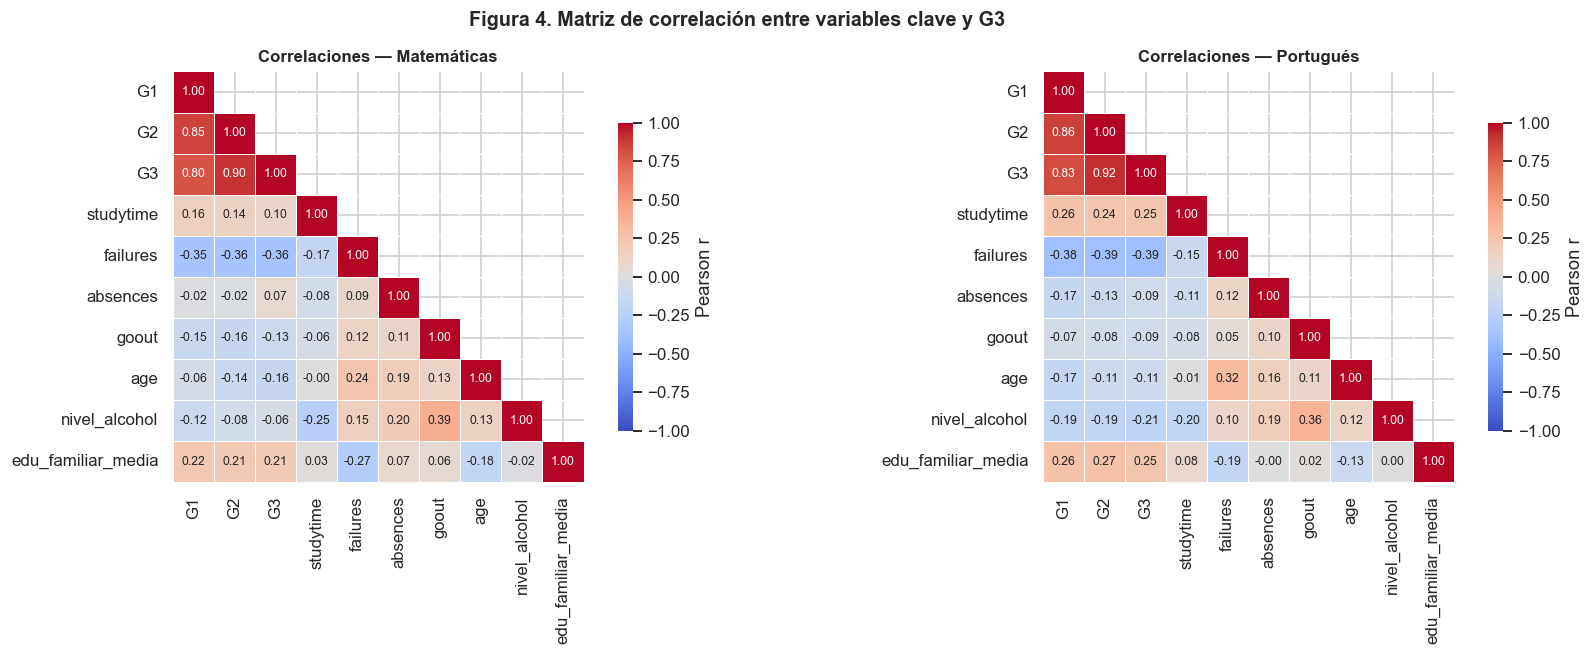

Ranking de correlación con G3 — Matemáticas:
G2                    0.905
G1                    0.801
failures             -0.360
edu_familiar_media    0.205
age                  -0.162
goout                -0.133
studytime             0.098
absences              0.070
nivel_alcohol        -0.058

Ranking de correlación con G3 — Portugués:
G2                    0.919
G1                    0.826
failures             -0.393
studytime             0.250
edu_familiar_media    0.249
nivel_alcohol        -0.209
age                  -0.107
absences             -0.095
goout                -0.088
Tramos de Correlación:
        0 → sin relación lineal.
        ±0,1 a ±0,3 → débil.
        ±0,3 a ±0,5 → moderada.
        ±0,5 a ±0,7 → fuerte.
        ±0,7 a ±1 → muy fuerte.

Interpretación (Fig. 4):
 G2 y G1 dominan ampliamente la matriz en ambas asignaturas (r=0,80–0,92).
 Entre las variables no académicas, failures es la correlación negativa más fuerte (r=-0,35 en Matemáticas, r=-0,39 en Portugué

In [19]:
# ──────────────────────────────────────────────────────────────
# FIGURA 4: Heatmap de correlaciones — variables clave con G3
# Responde: ¿Qué variables tienen mayor capacidad predictiva?
# ──────────────────────────────────────────────────────────────
#variables_clave = ['G1', 'G2', 'G3', 'Medu', 'Fedu', 'studytime',
#                   'failures', 'absences', 'Dalc', 'Walc', 'goout', 'age']

variables_clave = ['G1', 'G2', 'G3','studytime',
                   'failures', 'absences','goout', 'age','nivel_alcohol','edu_familiar_media']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df, titulo in zip(
        axes,
        [prep_mat.df_enc, prep_por.df_enc],
        ['Matemáticas', 'Portugués']):

    cols_disp = [c for c in variables_clave if c in df.columns]
    corr = df[cols_disp].corr()
    mascara = np.triu(np.ones_like(corr, dtype=bool), k=1)

    sns.heatmap(
        corr, mask=mascara, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5,
        annot_kws={'size': 8},
        cbar_kws={'label': 'Pearson r', 'shrink': 0.75},
        ax=ax
    )
    ax.set_title(f'Correlaciones — {titulo}', fontweight='bold', fontsize=11)

plt.suptitle('Figura 4. Matriz de correlación entre variables clave y G3',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}fig4_heatmap_correlaciones.png', dpi=110, bbox_inches='tight')
plt.show()

# Ranking de correlaciones con G3
print("Ranking de correlación con G3 — Matemáticas:")
corr_mat = prep_mat.df_enc[variables_clave].corr()['G3'].drop('G3').sort_values(key=abs, ascending=False)
print(corr_mat.round(3).to_string())

print("\nRanking de correlación con G3 — Portugués:")
corr_por = prep_por.df_enc[variables_clave].corr()['G3'].drop('G3').sort_values(key=abs, ascending=False)
print(corr_por.round(3).to_string())

print("""Tramos de Correlación:
        0 → sin relación lineal.
        ±0,1 a ±0,3 → débil.
        ±0,3 a ±0,5 → moderada.
        ±0,5 a ±0,7 → fuerte.
        ±0,7 a ±1 → muy fuerte.""")

print("""
Interpretación (Fig. 4):
 G2 y G1 dominan ampliamente la matriz en ambas asignaturas (r=0,80–0,92).
 Entre las variables no académicas, failures es la correlación negativa más fuerte (r=-0,35 en Matemáticas, r=-0,39 en Portugués).
 La variable derivada nivel_alcohol es la que efectivamente aparece en esta figura: su correlación con G3 es débil en Matemáticas (r=-0,06)
 y moderada en Portugués (r=-0,21). edu_familiar_media muestra asociación positiva moderada en ambas asignaturas (r=0,21 y r=0,25).
""")

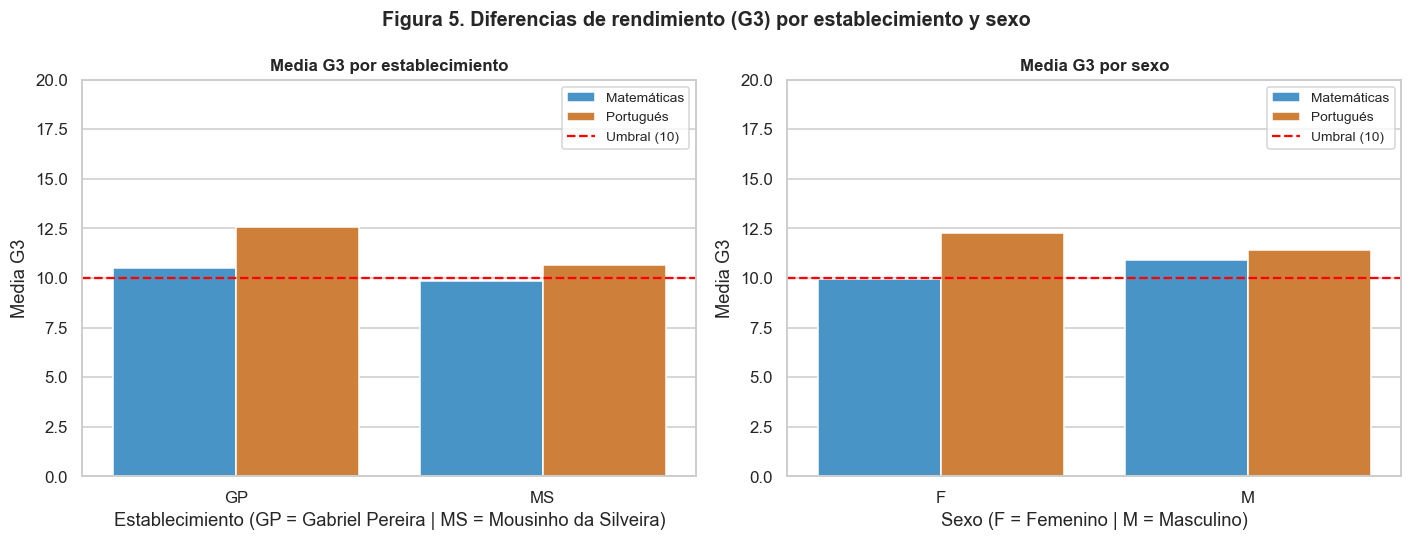


Interpretación (Fig. 5):
  El establecimiento GP supera al MS en ambas asignaturas, con una brecha más amplia en Portugués (≈12,6 vs. ≈10,7) 
 que en Matemáticas (≈10,5 vs. ≈9,9). Por sexo, la dirección de la diferencia depende de la asignatura, lo que sugiere 
 que el efecto del sexo sobre G3 no es un patrón general, sino específico al contexto de cada asignatura.



In [20]:
# ──────────────────────────────────────────────────────────────
# FIGURA 5: Rendimiento por establecimiento y por sexo
# Responde: ¿Existen diferencias entre escuelas y entre sexos?
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Parte A: media de G3 por escuela
g3_escuela = pd.concat([
    df_mat_raw.assign(Asignatura='Matemáticas'),
    df_por_raw.assign(Asignatura='Portugués')
]).groupby(['Asignatura', 'school'])['G3'].mean().reset_index()

sns.barplot(
    data=g3_escuela, x='school', y='G3', hue='Asignatura',
    palette=[PALETA['mat'], PALETA['por']], ax=axes[0]
)
axes[0].axhline(10, color='red', linestyle='--', linewidth=1.5, label='Umbral (10)')
axes[0].set_title('Media G3 por establecimiento', fontweight='bold', fontsize=11)
axes[0].set_xlabel('Establecimiento (GP = Gabriel Pereira | MS = Mousinho da Silveira)')
axes[0].set_ylabel('Media G3')
axes[0].set_ylim(0, 20)
axes[0].legend(fontsize=9)

# Parte B: media de G3 por sexo
g3_sexo = pd.concat([
    df_mat_raw.assign(Asignatura='Matemáticas'),
    df_por_raw.assign(Asignatura='Portugués')
]).groupby(['Asignatura', 'sex'])['G3'].mean().reset_index()

sns.barplot(
    data=g3_sexo, x='sex', y='G3', hue='Asignatura',
    palette=[PALETA['mat'], PALETA['por']], ax=axes[1]
)
axes[1].axhline(10, color='red', linestyle='--', linewidth=1.5, label='Umbral (10)')
axes[1].set_title('Media G3 por sexo', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Sexo (F = Femenino | M = Masculino)')
axes[1].set_ylabel('Media G3')
axes[1].set_ylim(0, 20)
axes[1].legend(fontsize=9)

plt.suptitle('Figura 5. Diferencias de rendimiento (G3) por establecimiento y sexo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}fig5_g3_escuela_sexo.png', dpi=110, bbox_inches='tight')
plt.show()

print("""
Interpretación (Fig. 5):
  El establecimiento GP supera al MS en ambas asignaturas, con una brecha más amplia en Portugués (≈12,6 vs. ≈10,7) 
 que en Matemáticas (≈10,5 vs. ≈9,9). Por sexo, la dirección de la diferencia depende de la asignatura, lo que sugiere 
 que el efecto del sexo sobre G3 no es un patrón general, sino específico al contexto de cada asignatura.
""")

---
<a id='7'></a>
## 7. Metodología, trazabilidad de mejoras y changelog

### 7.1 Metodología por fases

El proyecto siguió el ciclo ABP en cuatro fases incrementales:

| Fase | Estado del código | Observación formativa recibida | Acción de mejora aplicada |
|:---:|---|---|---|
| **F1** | Entorno + repositorio + carga inicial | Solo observaciones gramaticales, ninguna observacion técnica | Se mantuvo estructura técnica y se supervisa mejor la gramatica. |
| **F2** | Se centra el Pipeline funcional en `functions.py` | El notebook no se ejecuto de manera correcta (kernel->Restart & Run all) generando commit desordenados. Incohrencia de los terminos usados de normalizaciones y tratamiento de outliers en el informe. Verificación de excepciones(try)| Se verifica siempre que antes de hacer commit y push se ejecute el restart correctamente. Se ajusto concepto a winsorizacion en outliers y no a normalizacion. Se incluye verificacion de errores en las funciones. |
| **F3** | POO básica en `clases.py` + recursividad + benchmarks | COMPLETAR******* | Se añadió una clase Preprocesador y todas sus metodos reutilizados de las funnciones en functions.py |
| **F4** | Sistema integrado con validación, eficiencia y visualizaciones | — | Se incorporaron 5 visualizaciones analíticas, patrones de diseño y trazabilidad documentada |

### 7.2 Extracto del changelog

In [21]:
# ============================================================
# CHANGELOG — Trazabilidad de mejoras F1 → F4
# ============================================================
changelog = """
## [F4] - Junio 2026
### Added
- Patrón de diseño Strategy para imputación de nulos (EstrategiaImputacion, ImputarMediana, ImputarMedia)
- Batería de pruebas técnicas: 9 casos (normal, límite, excepción) con aserciones explícitas
- Benchmark merge_sort vs sorted() con análisis de complejidad y conteo de llamadas recursivas
- Benchmark vectorizado extendido a ambos datasets (Matemáticas y Portugués)
- 5 visualizaciones analíticas que responden a las preguntas de investigación de F1
- Trazabilidad completa del pipeline en tabla comparativa F1-F4

## [F3] - Junio 2026
### Added
- Clase PreprocesadorAsignatura (src/clases.py): encapsula el pipeline F2 en objetos
- Clases hijas PreprocesadorMatematicas y PreprocesadorPortugues: herencia + polimorfismo
- Método interpretar_resultados() como contrato de implementación (NotImplementedError en base)
- Algoritmo recursivo merge_sort aplicado a notas G3
- Comparativa de eficiencia bucle vs. vectorizado con timeit
- Método __repr__ para inspección del estado del objeto

## [F2] - Junio 2026
### Added
- Pipeline funcional completo en src/functions.py (12 funciones encapsuladas)
- Winsorización p95 para variable absences
- Flag 'desercion' (G2=0 y G3=0) para análisis diferenciado
- Codificación binaria (yes/no → 1/0) y One-Hot Encoding (Mjob, Fjob, reason, guardian)
- Variables derivadas: aprobado, progreso_g1_g3, nivel_alcohol, edu_familiar_media
- Función validar_dataset_final() con 7 asserts de integridad

## [F1] - Mayo 2026
### Added
- Configuración del entorno reproducible (.venv, requirements.txt, README.md)
- Repositorio GitHub con estructura modular (data/, notebooks/, src/)
- Carga inicial y exploración preliminar del Student Performance Dataset
- Definición formal del problema, preguntas de investigación y objetivos
"""

print(changelog)


## [F4] - Junio 2026
### Added
- Patrón de diseño Strategy para imputación de nulos (EstrategiaImputacion, ImputarMediana, ImputarMedia)
- Batería de pruebas técnicas: 9 casos (normal, límite, excepción) con aserciones explícitas
- Benchmark merge_sort vs sorted() con análisis de complejidad y conteo de llamadas recursivas
- Benchmark vectorizado extendido a ambos datasets (Matemáticas y Portugués)
- 5 visualizaciones analíticas que responden a las preguntas de investigación de F1
- Trazabilidad completa del pipeline en tabla comparativa F1-F4

## [F3] - Junio 2026
### Added
- Clase PreprocesadorAsignatura (src/clases.py): encapsula el pipeline F2 en objetos
- Clases hijas PreprocesadorMatematicas y PreprocesadorPortugues: herencia + polimorfismo
- Método interpretar_resultados() como contrato de implementación (NotImplementedError en base)
- Algoritmo recursivo merge_sort aplicado a notas G3
- Comparativa de eficiencia bucle vs. vectorizado con timeit
- Método __repr__ para inspecció

---
<a id='8'></a>
## 8. Resultados y discusión

### 8.1 Resultados del pipeline

El pipeline F1–F4 transforma los datos crudos en tablas completamente numéricas, limpias y validadas:

In [22]:
# ── Tabla de resultados del pipeline ─────────────────────────
resumen_pipeline = pd.DataFrame({
    'Métrica': [
        'Filas originales', 'Columnas originales',
        'Filas procesadas (df_enc)', 'Columnas procesadas (df_enc)',
        'Nulos originales', 'Nulos en df_enc',
        'Duplicados', 'Registros con G3=0',
        'Flag desercion', 'Aprobados (G3≥10)',
        'Winsorización absences (cap p95)',
    ],
    'Matemáticas': [
        prep_mat.df_raw.shape[0], prep_mat.df_raw.shape[1],
        prep_mat.df_enc.shape[0], prep_mat.df_enc.shape[1],
        prep_mat.df_raw.isnull().sum().sum(),
        prep_mat.df_enc.isnull().sum().sum(),
        prep_mat.df_raw.duplicated().sum(),
        (prep_mat.df_raw['G3'] == 0).sum(),
        prep_mat.df['desercion'].sum(),
        prep_mat.df_enc['aprobado'].sum(),
        f"{prep_mat.df['absences'].max():.0f} (original máx={prep_mat.df['absences_original'].max():.0f})",
    ],
    'Portugués': [
        prep_por.df_raw.shape[0], prep_por.df_raw.shape[1],
        prep_por.df_enc.shape[0], prep_por.df_enc.shape[1],
        prep_por.df_raw.isnull().sum().sum(),
        prep_por.df_enc.isnull().sum().sum(),
        prep_por.df_raw.duplicated().sum(),
        (prep_por.df_raw['G3'] == 0).sum(),
        prep_por.df['desercion'].sum(),
        prep_por.df_enc['aprobado'].sum(),
        f"{prep_por.df['absences'].max():.0f} (original máx={prep_por.df['absences_original'].max():.0f})",
    ]
})

resumen_pipeline

,Métrica,Matemáticas,Portugués
0,Filas originales,395,649
1,Columnas originales,33,33
2,Filas procesadas (df_enc),395,649
3,Columnas procesadas (df_enc),54,54
4,Nulos originales,0,0
5,Nulos en df_enc,0,0
6,Duplicados,0,0
7,Registros con G3=0,38,15
8,Flag desercion,13,7
9,Aprobados (G3≥10),265,549


### 8.2 Discusión de hallazgos

Los hallazgos se obtuvieron a partir de las correlaciones calculadas en la Fase 2 y las visualizaciones construidas en la Sección 6. Se organizan por pregunta de investigación.

**Hallazgo 1 — El desempeño previo la variable más influyente (PI4).** En ambas asignaturas, G2 y G1 presentan las correlaciones más altas con G3 (G2≈0.90 en Matemáticas, 0.92 en Portugués), confirmadas en el heatmap (Fig. 4). El rendimiento tiene alta autocorrelación temporal: los estudiantes que obtienen buenas notas en los primeros períodos tienden a mantenerlas al cierre del curso.

**Hallazgo 2 — Las reprobaciones previas configuran un perfil de riesgo multidimensional (PI1, PI2).** `failures` presenta la mayor correlación negativa con G3 en ambas asignaturas (≈−0.36 en Matemáticas, −0.39 en Portugués). El radar comparativo (Fig. 3) muestra que los estudiantes con 3 o más reprobaciones no solo obtienen notas más bajas, sino que también dedican menos tiempo al estudio, provienen de hogares con menor educación parental y consumen más alcohol en la semana. Este patrón se reproduce en ambas asignaturas, lo que refuerza su robustez como hallazgo transversal.

**Hallazgo 3 — Los hábitos de estudio tienen mayor impacto en Portugués (PI2).** `studytime` presenta una correlación de 0.25 con G3 en Portugués frente a 0.10 en Matemáticas. El radar por asignatura (Fig. 6) lo hace visible: el polígono de Portugués es más amplio en el eje 'Tiempo de estudio', indicando que en esa asignatura el hábito de estudio marca una diferencia más pronunciada entre estudiantes.

**Hallazgo 4 — El consumo de alcohol se asocia negativamente con el rendimiento, especialmente en Portugués (PI2).** La variable nivel_alcohol (promedio de Dalc y Walc, ver Figura 4) muestra una correlación con G3 casi nula en Matemáticas (r=-0,06) y moderada en Portugués (r=-0,21). El radar comparativo (Figura 3) complementa este hallazgo: el grupo con 3 o más reprobaciones presenta consistentemente mayor consumo de alcohol que el grupo sin reprobaciones, en ambas asignaturas.

**Hallazgo 5 — El capital educativo familiar se asocia con trayectorias académicas más exitosas (PI1).** La variable `edu_familiar_media` muestra que los estudiantes sin reprobaciones provienen de hogares con mayor nivel educativo parental promedio, visible en el eje 'Educ. Padres' del radar (Fig. 3). Este resultado es coherente con la literatura sobre el rol del capital cultural en trayectorias educativas.

**Hallazgo 6 — Existen diferencias de rendimiento entre establecimientos y por sexo (PI3).** El establecimiento GP presenta medias de G3 superiores al MS en ambas asignaturas (Fig. 5). Las estudiantes femeninas obtienen medias más altas en Portugués; en Matemáticas las diferencias son mínimas.

**Limitaciones.** Las correlaciones de Pearson solo capturan relaciones lineales; efectos no lineales podrían estar subestimados. El dataset cubre un contexto geográfico específico (Portugal, 2008), lo que restringe la generalización. Las variables de hábitos son autodeclaradas y pueden presentar sesgo de deseabilidad social. Cuando el notebook se ejecuta con datos sintéticos, los valores numéricos de la tabla de resultados son aproximados y no reemplazan el análisis sobre los datos reales.

**Líneas futuras.** Los datos en `df_enc` constituyen la entrada directa para modelos predictivos supervisados (regresión lineal múltiple, árboles de decisión) que permitirían cuantificar el peso relativo de cada variable sobre G3 con mayor rigor estadístico.

---
<a id='9'></a>
## 9. Conclusiones y reflexión crítica

El proyecto consolidó un sistema reproducible, modular y robusto que integra las cuatro fases del ABP sobre el Student Performance Dataset. Esta sección organiza las conclusiones técnicas explícitamente según los cuatro resultados de aprendizaje (RA) del curso, de forma que la evidencia construida en el código quede verbalizada como aprendizaje logrado.

### 9.1 Conclusiones técnicas

El proyecto se gestionó íntegramente bajo control de versiones Git/GitHub, con una convención de commits descriptivos por tipo de cambio (feat:, refactor:) sostenida desde F1 hasta F4, y un repositorio organizado en carpetas por fase (data/, notebooks/, src/) que permite auditar la evolución del proyecto en cualquier punto del historial. La gestión con Jupyter Notebooks se complementó con un entorno virtual documentado (requirements.txt). El respaldo automático con datos sintéticos asegura que el pipeline se ejecute de principio a fin incluso si los archivos CSV originales no están disponibles, sin intervención manual.

El algoritmo recursivo merge_sort se validó contra sorted de Python sobre las calificaciones G3 de ambas asignaturas, confirmando equivalencia de resultados. El benchmark comparó la determinación de aprobación (G3 ≥ 10) mediante bucle iterrows() versus operación vectorizada, sobre ambos datasets: misma complejidad asintótica O(n) en ambas implementaciones, pero con una diferencia de varios órdenes de magnitud en tiempo real de ejecución, justificando la adopción de la versión vectorizada en todo el pipeline. Durante todo el proyecto, se encapsularon las funciones para que su ejecución fuese eficiente y ordenada, lo que permite la reutilización de las mismas y en las fases posteriores. 

La arquitectura del proyecto implementa los cuatro pilares de la POO: encapsulamiento (atributos df, df_raw, df_enc gestionados internamente por los métodos del pipeline), herencia (PreprocesadorMatematicas y PreprocesadorPortugues heredan de PreprocesadorAsignatura sin duplicar lógica), polimorfismo (interpretar_resultados() con la misma firma y comportamiento distinto por asignatura) y abstracción (EstrategiaImputacion como interfaz abstracta del patrón Strategy, además de interpretarresultados). La batería de pruebas técnicas verificó explícitamente que la clase base lanza NotImplementedError si una subclase no implementa el contrato, evidencia de que el diseño no es solo declarativo, sino verificado en código.

Las visualizaciones del proyecto se diseñaron para responder directamente a las preguntas de investigación definidas en F1, no como gráficos exploratorios genéricos. Se combinaron las librerías Matplotlib (para anotaciones de valores y líneas de referencia) y Seaborn (para comparaciones estadísticas con escalas consistentes), incluyendo un radar comparativo que resuelve un problema de comunicación que ningún gráfico bivariado puede resolver por sí solo: mostrar simultáneamente varias variables y cómo se mueven juntas. Cada figura incluye título descriptivo, ejes etiquetados, leyenda e interpretación escrita vinculada a las preguntas de investigación definidas en la Fase 1.

### 9.2 Conclusiones sustantivas



Los análisis responden directamente a las cuatro preguntas de investigación definidas en F1:

| Pregunta | Respuesta sintetizada |
|:---:|---|
| **PI1** — Factores socioeconómicos y familiares | El nivel educativo parental (edu_familiar_media) muestra asociación positiva moderada con G3 (r=0,205 Mat, r= 0,249 Por). Los estudiantes con 3+ reprobaciones provienen sistemáticamente de hogares con menor capital educativo parental. |
| **PI2** — Hábitos de estudio y alcohol | El tiempo de estudio se asocia positivamente con G3, con peso desigual (r=0,10 Mat, r=0,25 Por). El consumo de alcohol (nivel_alcohol) se asocia negativamente, de forma casi nula en Matemáticas (r=-0,06) y moderada en Portugués (r=-0,21). |
| **PI3** — Diferencias entre asignaturas y establecimientos | Portugués presenta mayor tasa de aprobación (84,6% vs. 67,1%) y mayor media de G3 (11,9 vs. 10,4). El establecimiento GP supera al MS en ambas asignaturas, con brecha mayor en Portugués. El efecto del sexo sobre G3 se invierte entre asignaturas: favorece a las mujeres en Portugués y a los hombres en Matemáticas, en magnitud comparable a la del establecimiento. |
| **PI4** — Variables con mayor capacidad predictiva de G3 | G2 y G1 son los variables más explicativas (r≈0,90–0,92 y r≈0,80–0,83). failures es el factor de riesgo no académico más fuerte (r≈-0,36 a -0,39). Ninguna variable socioeconómica aislada se acerca al poder explicativo del desempeño previo. |

### 9.3 Reflexión crítica del equipo

**Fortalezas:** la trazabilidad sostenida entre notebook, módulos y repositorio facilita la auditoría del proceso. La separación entre funciones (F2), objetos (F3) y patrones de diseño (F4) permite que cada capa sea probada y documentada de forma independiente. El respaldo sintético agrega un estándar profesional de reproducibilidad que va más allá de lo estrictamente requerido. El algortimo desarrollado quedo con un alto nivel de escalabilidad permitiendo agregar nuevos dataset, con una misma estrucutra de datos, solo creando una nueva subclase para asignaturas nuevas.

**Dificultades:** la integración del generador de datos sintéticos requirió calibrar la clase y funciones para que este notebook sea reproducible sin depender que el dataset este correcto. 

**Líneas de mejora:** (1) Entrenar modelos de regresión lineal múltiple y árboles de decisión sobre `df_enc` para cuantificar el peso relativo de cada variable sobre G3. (2) Explorar el merge de ambos datasets para análisis comparativos más robustos entre asignaturas controlando covariables. (3) Adicionalmente, el estudio del subconjunto de estudiantes comunes a ambas asignaturas permitiría realizar análisis más detallados y explorar con mayor profundidad los factores asociados al rendimiento académico individual.

---
<a id='10'></a>
## 10. Bibliografía (APA 7.ª edición)


Cooper, J. W. (2021). *Python programming with design patterns*. Addison-Wesley Professional.

Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2022). *Introduction to algorithms* (4th ed.). MIT Press.

Cortez, P., & Silva, A. M. G. (2008). Using data mining to predict secondary school student performance. In A. Brito & J. Teixeira (Eds.), *Proceedings of the 5th Future Business Technology Conference (FUBUTEC 2008)* (pp. 5–12). EUROSIS.

Dua, D., & Graff, C. (2019). *UCI Machine Learning Repository*. University of California, Irvine, School of Information and Computer Sciences. https://archive.ics.uci.edu

García, S., Luengo, J., & Herrera, F. (2015). *Data preprocessing in data mining*. Springer.

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., & Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

NumPy Developers. (2024). *NumPy documentation*. https://numpy.org/doc/stable/

Nygard, M. (2011, November 15). *Documenting architecture decisions* [Blog post]. Cognitect. https://cognitect.com/blog/2011/11/15/documenting-architecture-decisions

The pandas development team. (2024). *pandas documentation*. https://pandas.pydata.org/docs/

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Python Software Foundation. (2026). *The Python standard library*. https://docs.python.org/3/library/

Richards, M., & Ford, N. (2025). *Fundamentals of software architecture: A modern engineering approach* (2nd ed.). O'Reilly Media.

Romero, C., & Ventura, S. (2020). Educational data mining and learning analytics: An updated survey. *WIREs Data Mining and Knowledge Discovery, 10*(3), e1355. https://doi.org/10.1002/widm.1355

Salinas, O. (2026a). *Programación orientada a objetos (POO) aplicada a la ciencia de datos* [Infografía]. Universidad Andrés Bello.

Salinas, O. (2026b). *Transformaciones avanzadas en ciencia de datos* [Infografía]. Universidad Andrés Bello.

Universidad Andrés Bello. (2026a). *Guía de Git y GitHub: Entorno de desarrollo con Python y JupyterLab* [Material docente].

Universidad Andrés Bello. (2026b). *Documentación profesional de arquitectura en ciencia de datos* [Infografía]. UNAB Online.

Waskom, M. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software, 6*(60), 3021. https://doi.org/10.21105/joss.03021
